# 07 Customer Lifetime Value (CLV) Prediction - Customer Lifetime Value Prediction

## Project Overview

Customer Lifetime Value (CLV) prediction aims to estimate how much value each customer may generate for the business in a future period. This part is important because CLV is not only a modeling target, but also a core business metric for customer management, budget allocation, retention prioritization, and long-term growth planning. In this section, we first clarify the business objective of the project, define what CLV means in this notebook, summarize the main business value and technical challenges, and explain what outputs this project is expected to deliver. This gives a clear foundation before moving into data preparation, feature engineering, modeling, and strategy design.

## Project Objectives

This project aims to predict each customer's future value contribution and support the following business decisions:

1. Identify high-value, medium-value, and low-value customers
2. Optimize marketing budget allocation for higher ROI
3. Evaluate whether customer acquisition cost is reasonable
4. Identify VIP customers and support personalized service
5. Combine CLV with churn risk for value-risk management

## Business Value

- A small group of top customers may contribute a large share of total revenue
- Marketing resources can be allocated more efficiently
- High-CLV customers can receive stronger retention support
- CLV can be combined with churn prediction to guide intervention priority

## Technical Challenges

1. Choosing a suitable CLV definition
2. Designing training and prediction time windows
3. Building features from multiple data sources
4. Selecting suitable regression models
5. Evaluating both model accuracy and business usefulness

## Key Outputs

- Predicted CLV score for each customer
- Customer value tiers such as Platinum, Gold, Silver, and Bronze
- Value-risk matrix based on CLV and churn probability
- Budget allocation suggestions for different customer groups
- High-value customer list and customer profile analysis

# 1. CLV Foundation and Metric Definition

In this part, I define what Customer Lifetime Value means in this project and explain how the prediction target is constructed. This section is necessary because CLV can be measured in different ways, and the model result is only meaningful when the business definition is clear. Here, we briefly compare several common CLV methods, explain why this project uses future GMV as the target, and define both the regression and business evaluation metrics for later model assessment.

## 1.1 Overview of CLV Calculation Methods

There are several common ways to calculate CLV, and each method fits a different business scenario.

**Method 1: Historical CLV**

```text
Historical CLV = Total historical customer spending - Total cost
Simplified version:
Historical CLV = Σ(Order Value) - Σ(Customer Acquisition Cost + Service Cost)
```

**Method 2: Predictive CLV**

```text
Predictive CLV = Σ(Expected profit in future periods) × Retention probability
Classic formula:
CLV = (ARPU × Gross Margin) × (1 / Churn Rate)
```
**Method 3: Simplified RFM-based CLV**

```text
Simplified CLV = Average Order Value × Purchase Frequency × Customer Lifetime
               = Monetary × Frequency × (1 / Recency decay factor)
```

## 1.2 CLV Definition Used in This Project

In this project, the target variable is defined as future 6-month GMV.

This definition is chosen for three main reasons:

- The data is available from historical order records
- The target is easy to explain in business terms
- It can be combined with churn prediction for value-risk analysis

**Label Construction Logic**

```text
Training set:
Use customer behavior in T0-T1 to predict GMV in T1-T2

Example window design
Feature window: 2017-01-01 to 2017-06-30
Label window:   2017-07-01 to 2017-12-31

If data allows, a later rolling window can also be tested
Example:
Feature window: 2017-07-01 to 2017-12-31
Label window:   2018-01-01 to 2018-06-30
```

This means the model learns from past customer behavior and predicts the value generated in the next period, rather than describing historical spending only.

## 1.3 Evaluation Metric Design

To evaluate model performance, this project uses both regression metrics and business metrics.

**Regression Metrics**

- MAE (Mean Absolute Error): average absolute prediction error
- RMSE (Root Mean Squared Error): penalizes large errors more strongly
- MAPE (Mean Absolute Percentage Error): relative prediction error in percentage terms
- R² Score: overall goodness of fit

**Business Metrics**

- Top 10% CLV identification accuracy
- Tier consistency between predicted and actual customer value groups
- Segment-level MAPE across different value ranges

This metric design is important because a model with acceptable regression error may still perform poorly in customer ranking or customer tier assignment.

# 2 Data Preparation and Data Loading

This section prepares the project for modeling by setting up the notebook environment, loading the required data, and conducting an initial data check. This part is necessary because CLV prediction depends on reliable feature tables, correct target labels, and consistent data structure. In this section, we import the main libraries, connect to the database, load feature and label data, and perform an initial exploration of dataset size, missing values, and target availability.

## 2.1 Environment Setup, Data Loading, and Initial Exploration

Before feature engineering and model training, the notebook first sets up the Python environment, connects to the data warehouse, and loads the historical customer feature view together with the future 6-month GMV label view. These two views are merged into one customer-level modeling table for downstream analysis.

This step is not only about loading data, but also about confirming that the analytical unit, feature scope, and target window are aligned. Initial inspection helps verify dataset shape, column structure, and variable meaning before moving to more advanced modeling stages. In CLV work, small inconsistencies at the loading stage can later distort both model performance and business interpretation, so an early structural check is necessary.

In [1]:
# 2.1.1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime, timedelta

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 2.1.2 Connect to database
from src.utils.db import get_engine

engine = get_engine()
print("Database connection created successfully.")

Database connection created successfully.


In [3]:
# 2.1.2A Define snapshot window
FEATURE_END = pd.Timestamp('2017-06-30')
LABEL_START = pd.Timestamp('2017-07-01')
LABEL_END = pd.Timestamp('2017-12-31')

assert LABEL_START == FEATURE_END + pd.Timedelta(days=1)

print("Feature window end:", FEATURE_END.date())
print("Label window start:", LABEL_START.date())
print("Label window end:", LABEL_END.date())

Feature window end: 2017-06-30
Label window start: 2017-07-01
Label window end: 2017-12-31


In [4]:
# 2.1.3 Load prepared feature view
FEATURE_END = '2017-06-30'
LABEL_START = '2017-07-01'
LABEL_END = '2017-12-31'

sql_features = f"""
SELECT *
FROM view_user_clv_features
WHERE first_order_date < '{LABEL_START}'
  AND last_order_date <= '{FEATURE_END}'
"""

df_features = pd.read_sql(sql_features, engine)

print("Feature dataset loaded.")
print(f"df_features shape: {df_features.shape}")
df_features.head()

Feature dataset loaded.
df_features shape: (13763, 18)


,customer_unique_id,total_orders,total_gmv,avg_order_value,first_order_date,last_order_date,customer_lifetime_days,days_since_last_order,monthly_frequency,unique_products_purchased,unique_categories_purchased,avg_payment_value,max_installments_used,avg_review_score,satisfaction_rate,bad_review_count,avg_delivery_delay,delay_rate
0,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,113,30.0,1,1,86.22,8.0,3.0,0.0,0.0,-2.0,0.0
1,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,2017-03-04 23:32:12,2017-03-04 23:32:12,0,119,30.0,1,1,150.12,3.0,4.0,1.0,0.0,-28.0,0.0
2,00115fc7123b5310cf6d3a3aa932699e,1,76.11,76.11,2017-01-21 21:58:35,2017-01-21 21:58:35,0,161,30.0,1,1,76.11,1.0,4.0,1.0,0.0,-33.0,0.0
3,0011805441c0d1b68b48002f1d005526,1,297.14,297.14,2017-04-24 13:36:48,2017-04-24 13:36:48,0,68,30.0,1,1,297.14,10.0,3.0,0.0,0.0,-13.0,0.0
4,0011857aff0e5871ce5eb429f21cdaf5,1,192.83,192.83,2017-06-28 11:08:38,2017-06-28 11:08:38,0,3,30.0,1,1,192.83,3.0,5.0,1.0,0.0,-20.0,0.0


In [5]:
# 2.1.3A Validate raw snapshot baseline from SQL view

if 'days_since_last_order' in df_features.columns:
    raw_dslo = pd.to_numeric(df_features['days_since_last_order'], errors='coerce')

    print("Raw SQL-view days_since_last_order summary:")
    print(raw_dslo.describe())

    suspicious_baseline = bool(
        raw_dslo.dropna().gt(365).mean() > 0.50 or
        raw_dslo.max(skipna=True) > 365
    )

    if suspicious_baseline:
        print(
            "\nWARNING: view_user_clv_features looks misaligned with the 2017 snapshot. "
            "Please fix sql/create_views.sql by replacing CURDATE() with '2017-07-01' "
            "and recreate the view before trusting final outputs."
        )
    else:
        print("\nSQL view baseline looks consistent with the 2017 observation window.")
else:
    print("days_since_last_order is not present in df_features; skip raw SQL-view validation.")

Raw SQL-view days_since_last_order summary:
count    13763.000000
mean        76.238756
std         52.336732
min          2.000000
25%         34.000000
50%         67.000000
75%        111.000000
max        289.000000
Name: days_since_last_order, dtype: float64

SQL view baseline looks consistent with the 2017 observation window.


In [6]:
sql_labels = """
SELECT *
FROM view_user_future_gmv
"""
df_labels = pd.read_sql(sql_labels, engine)

print(df_labels.shape)
df_labels.head()

(93358, 4)


,customer_unique_id,future_6m_gmv,future_6m_orders,is_active_future
0,0000366f3b9a7992bf8c76cfdf3221e2,0.00,0,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,0.00,0,0
2,0000f46a3911fa3c0805444483337064,0.00,0,0
3,0000f6ccb0745a6a4b88665a16c9f078,43.62,1,1
4,0004aac84e0df4da2b147fca70cf8255,196.89,1,1


In [7]:
print("Label columns:")
print(df_labels.columns.tolist())

label_check_cols = [
    col for col in [
        'customer_unique_id',
        'future_6m_gmv',
        'future_6m_orders',
        'is_active_future'
    ] if col in df_labels.columns
]

print("\nLabel preview:")
print(df_labels[label_check_cols].head())

print("\nLabel summary:")
print(df_labels[[col for col in ['future_6m_gmv', 'future_6m_orders', 'is_active_future'] if col in df_labels.columns]].describe())

print("\nPositive future GMV count in labels:", (df_labels['future_6m_gmv'] > 0).sum())
print("Positive future GMV rate in labels:", (df_labels['future_6m_gmv'] > 0).mean())
print("Max future GMV in labels:", df_labels['future_6m_gmv'].max())

Label columns:
['customer_unique_id', 'future_6m_gmv', 'future_6m_orders', 'is_active_future']

Label preview:
                 customer_unique_id  future_6m_gmv  future_6m_orders  \
0  0000366f3b9a7992bf8c76cfdf3221e2           0.00                 0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f           0.00                 0   
2  0000f46a3911fa3c0805444483337064           0.00                 0   
3  0000f6ccb0745a6a4b88665a16c9f078          43.62                 1   
4  0004aac84e0df4da2b147fca70cf8255         196.89                 1   

   is_active_future  
0                 0  
1                 0  
2                 0  
3                 1  
4                 1  

Label summary:
       future_6m_gmv  future_6m_orders  is_active_future
count   93358.000000      93358.000000      93358.000000
mean       49.923611          0.315934          0.308061
std       142.760324          0.483525          0.461695
min         0.000000          0.000000          0.000000
25%         0.000000   

In [8]:
df = df_features.merge(df_labels, on='customer_unique_id', how='inner')
print(df.shape)
df.head()

(13763, 21)


,customer_unique_id,total_orders,total_gmv,avg_order_value,first_order_date,last_order_date,customer_lifetime_days,days_since_last_order,monthly_frequency,unique_products_purchased,...,avg_payment_value,max_installments_used,avg_review_score,satisfaction_rate,bad_review_count,avg_delivery_delay,delay_rate,future_6m_gmv,future_6m_orders,is_active_future
0,0000f46a3911fa3c0805444483337064,1,86.22,86.22,2017-03-10 21:05:03,2017-03-10 21:05:03,0,113,30.0,1,...,86.22,8.0,3.0,0.0,0.0,-2.0,0.0,0.0,0,0
1,0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12,2017-03-04 23:32:12,2017-03-04 23:32:12,0,119,30.0,1,...,150.12,3.0,4.0,1.0,0.0,-28.0,0.0,0.0,0,0
2,00115fc7123b5310cf6d3a3aa932699e,1,76.11,76.11,2017-01-21 21:58:35,2017-01-21 21:58:35,0,161,30.0,1,...,76.11,1.0,4.0,1.0,0.0,-33.0,0.0,0.0,0,0
3,0011805441c0d1b68b48002f1d005526,1,297.14,297.14,2017-04-24 13:36:48,2017-04-24 13:36:48,0,68,30.0,1,...,297.14,10.0,3.0,0.0,0.0,-13.0,0.0,0.0,0,0
4,0011857aff0e5871ce5eb429f21cdaf5,1,192.83,192.83,2017-06-28 11:08:38,2017-06-28 11:08:38,0,3,30.0,1,...,192.83,3.0,5.0,1.0,0.0,-20.0,0.0,0.0,0,0


In [9]:
print("Merged target summary:")
print(df['future_6m_gmv'].describe())

print("\nPositive future GMV count after merge:", (df['future_6m_gmv'] > 0).sum())
print("Positive future GMV rate after merge:", (df['future_6m_gmv'] > 0).mean())

print("\nFuture activity rate after merge:")
if 'is_active_future' in df.columns:
    print(df['is_active_future'].mean())

Merged target summary:
count    13763.000000
mean         2.789415
std         33.888546
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1535.880000
Name: future_6m_gmv, dtype: float64

Positive future GMV count after merge: 220
Positive future GMV rate after merge: 0.01598488701591223

Future activity rate after merge:
0.01598488701591223


In [10]:
print("Column overview:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nTarget summary:")
print(df['future_6m_gmv'].describe())

print(f"\nShare of zero future GMV customers: {(df['future_6m_gmv'] == 0).mean():.2%}")
print(f"Share of active future customers: {df['is_active_future'].mean():.2%}")

Column overview:
['customer_unique_id', 'total_orders', 'total_gmv', 'avg_order_value', 'first_order_date', 'last_order_date', 'customer_lifetime_days', 'days_since_last_order', 'monthly_frequency', 'unique_products_purchased', 'unique_categories_purchased', 'avg_payment_value', 'max_installments_used', 'avg_review_score', 'satisfaction_rate', 'bad_review_count', 'avg_delivery_delay', 'delay_rate', 'future_6m_gmv', 'future_6m_orders', 'is_active_future']

Data types:
customer_unique_id                 str
total_orders                     int64
total_gmv                      float64
avg_order_value                float64
first_order_date                   str
last_order_date                    str
customer_lifetime_days           int64
days_since_last_order            int64
monthly_frequency              float64
unique_products_purchased        int64
unique_categories_purchased      int64
avg_payment_value              float64
max_installments_used          float64
avg_review_score     

In [11]:
engine.dispose()
print("Database connection closed.")

Database connection closed.


In [12]:
print(df_features.shape)
print(df_labels.shape)
print(df.shape)
print(df.isnull().sum().sort_values(ascending=False).head(20))

(13763, 18)
(93358, 4)
(13763, 21)
avg_review_score               104
max_installments_used            1
avg_delivery_delay               1
avg_payment_value                1
customer_unique_id               0
first_order_date                 0
avg_order_value                  0
total_gmv                        0
total_orders                     0
monthly_frequency                0
days_since_last_order            0
last_order_date                  0
customer_lifetime_days           0
unique_products_purchased        0
unique_categories_purchased      0
satisfaction_rate                0
bad_review_count                 0
delay_rate                       0
future_6m_gmv                    0
future_6m_orders                 0
dtype: int64


## 2.2 Data Quality Check and Missing Value Handling

Before feature engineering and model training, the dataset requires a basic quality review. In this subsection, we check duplicate customers, convert date columns into datetime format, inspect missing values, and apply simple imputation rules to a small number of core variables.

This step also serves a broader purpose: it tests whether the dataset is internally consistent enough for CLV modeling. In particular, date-related variables must be interpreted carefully, because customer recency and lifetime features are highly sensitive to the chosen time reference. For that reason, data quality in this project is not only about completeness, but also about whether the temporal logic of the dataset matches the prediction task.

In [13]:
# 2.2.1 Create a working copy
df_clean = df.copy()

print(f"Original dataset shape: {df.shape}")
print(f"Working dataset shape: {df_clean.shape}")

Original dataset shape: (13763, 21)
Working dataset shape: (13763, 21)


In [14]:
# 2.2.3 Convert date columns to datetime
date_columns = ['first_order_date', 'last_order_date']

for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

print(df_clean[date_columns].dtypes)

first_order_date    datetime64[us]
last_order_date     datetime64[us]
dtype: object


In [15]:
# 2.2.3A Snapshot consistency check and repair

FEATURE_END = pd.Timestamp('2017-06-30')
LABEL_START = pd.Timestamp('2017-07-01')
LABEL_END = pd.Timestamp('2017-12-31')
OBSERVATION_CUTOFF = LABEL_START
ACTIVE_THRESHOLD_DAYS = 180

assert LABEL_START == FEATURE_END + pd.Timedelta(days=1)

# 1) check leakage
leak_mask = (
    df_clean['last_order_date'].notna() &
    (df_clean['last_order_date'] > FEATURE_END)
)
leak_count = int(leak_mask.sum())

print("Customers with last_order_date after FEATURE_END:", leak_count)

if leak_count > 0:
    print("\nWarning: leakage customers detected. They will be excluded from modeling.\n")

    leak_preview_cols = [
        'customer_unique_id',
        'first_order_date',
        'last_order_date',
        'total_orders',
        'total_gmv',
        'future_6m_gmv'
    ]

    leak_preview_cols = [col for col in leak_preview_cols if col in df_clean.columns]
    print(df_clean.loc[leak_mask, leak_preview_cols].head(10))

    # drop leakage rows instead of stopping the notebook
    df_clean = df_clean.loc[~leak_mask].copy()

print("\nDataset shape after leakage filtering:", df_clean.shape)

# final validation
remaining_leak = int((df_clean['last_order_date'] > FEATURE_END).sum())
print("Remaining leakage rows:", remaining_leak)

# 2) rebuild snapshot-based time features
df_clean['customer_lifetime_days_snap'] = (
    (df_clean['last_order_date'] - df_clean['first_order_date']).dt.days
)
df_clean['customer_lifetime_days_snap'] = (
    df_clean['customer_lifetime_days_snap'].fillna(0).clip(lower=0)
)

df_clean['days_since_last_order_snap'] = (
    (FEATURE_END - df_clean['last_order_date']).dt.days
)
df_clean['days_since_last_order_snap'] = (
    df_clean['days_since_last_order_snap'].fillna(0).clip(lower=0)
)

observed_months = np.maximum(
    (df_clean['customer_lifetime_days_snap'] + 30) / 30,
    1
)
df_clean['monthly_frequency_snap'] = (
    df_clean['total_orders'] / observed_months
)

# 3) add canonical aliases for downstream sections
df_clean['customer_lifetime_days'] = df_clean['customer_lifetime_days_snap']
df_clean['days_since_last_order'] = df_clean['days_since_last_order_snap']
df_clean['monthly_frequency'] = df_clean['monthly_frequency_snap']

# 4) activity diagnostics at the snapshot cutoff
df_clean['days_since_last_order_at_cutoff'] = (
    OBSERVATION_CUTOFF - df_clean['last_order_date']
).dt.days
df_clean['days_since_last_order_at_cutoff'] = (
    df_clean['days_since_last_order_at_cutoff'].fillna(0).clip(lower=0)
)

active_mask = df_clean['days_since_last_order_at_cutoff'] <= ACTIVE_THRESHOLD_DAYS

print("\nSnapshot feature summary:")
print(
    df_clean[
        [
            'customer_lifetime_days_snap',
            'days_since_last_order_snap',
            'monthly_frequency_snap'
        ]
    ].describe()
)

print("\nActivity diagnostic at observation cutoff:")
print(f"Original customers: {len(df_clean):,}")
print(f"Active customers (<= {ACTIVE_THRESHOLD_DAYS} days): {active_mask.sum():,}")
print(f"Active customer rate: {active_mask.mean():.2%}")

print("\nDays since last order diagnostic:")
print(df_clean['days_since_last_order'].describe())
print(f"Inactive > 365 days: {(df_clean['days_since_last_order'] > 365).sum():,}")
print(f"Inactive > 180 days: {(df_clean['days_since_last_order'] > 180).sum():,}")
print(f"Inactive > 90 days: {(df_clean['days_since_last_order'] > 90).sum():,}")

Customers with last_order_date after FEATURE_END: 0

Dataset shape after leakage filtering: (13763, 21)
Remaining leakage rows: 0

Snapshot feature summary:
       customer_lifetime_days_snap  days_since_last_order_snap  \
count                 13763.000000                13763.000000   
mean                      0.387125                   74.238756   
std                       5.325268                   52.336732   
min                       0.000000                    0.000000   
25%                       0.000000                   32.000000   
50%                       0.000000                   65.000000   
75%                       0.000000                  109.000000   
max                     182.000000                  287.000000   

       monthly_frequency_snap  
count            13763.000000  
mean                 1.015357  
std                  0.140137  
min                  0.283019  
25%                  1.000000  
50%                  1.000000  
75%                  1.0

In [16]:
# 2.2.4 Missing value summary
missing_summary = pd.DataFrame({
    'missing_count': df_clean.isnull().sum(),
    'missing_ratio': df_clean.isnull().mean()
}).sort_values(by='missing_count', ascending=False)

missing_summary = missing_summary[missing_summary['missing_count'] > 0]

print("Missing value summary:")
print(missing_summary)

Missing value summary:
                       missing_count  missing_ratio
avg_review_score                 104       0.007556
avg_payment_value                  1       0.000073
avg_delivery_delay                 1       0.000073
max_installments_used              1       0.000073


In [17]:
# 2.2.5 Basic numeric quality check
numeric_summary = df_clean.describe().T
print(numeric_summary)

                                   count                        mean  \
total_orders                     13763.0                    1.024922   
total_gmv                        13763.0                   166.57044   
avg_order_value                  13763.0                  163.148919   
first_order_date                   13763  2017-04-16 00:14:43.317227   
last_order_date                    13763  2017-04-16 09:40:11.337862   
customer_lifetime_days           13763.0                    0.387125   
days_since_last_order            13763.0                   74.238756   
monthly_frequency                13763.0                    1.015357   
unique_products_purchased        13763.0                    1.092858   
unique_categories_purchased      13763.0                    1.016203   
avg_payment_value                13762.0                   163.20739   
max_installments_used            13762.0                    3.157753   
avg_review_score                 13659.0                    4.19

In [18]:
# 2.2.6 Handle missing values in core features

# Review-related fields
if 'avg_review_score' in df_clean.columns:
    df_clean['avg_review_score'] = df_clean['avg_review_score'].fillna(df_clean['avg_review_score'].median())

if 'satisfaction_rate' in df_clean.columns:
    df_clean['satisfaction_rate'] = df_clean['satisfaction_rate'].fillna(df_clean['satisfaction_rate'].median())

if 'bad_review_count' in df_clean.columns:
    df_clean['bad_review_count'] = df_clean['bad_review_count'].fillna(0)

# Delivery-related fields
if 'avg_delivery_delay' in df_clean.columns:
    df_clean['avg_delivery_delay'] = df_clean['avg_delivery_delay'].fillna(0)

if 'delay_rate' in df_clean.columns:
    df_clean['delay_rate'] = df_clean['delay_rate'].fillna(0)

# Payment-related fields
if 'avg_payment_value' in df_clean.columns:
    df_clean['avg_payment_value'] = df_clean['avg_payment_value'].fillna(df_clean['avg_payment_value'].median())

if 'max_installments_used' in df_clean.columns:
    df_clean['max_installments_used'] = df_clean['max_installments_used'].fillna(df_clean['max_installments_used'].median())

In [19]:
# 2.2.7 Validate missing values after imputation
remaining_missing = pd.DataFrame({
    'missing_count': df_clean.isnull().sum(),
    'missing_ratio': df_clean.isnull().mean()
}).sort_values(by='missing_count', ascending=False)

remaining_missing = remaining_missing[remaining_missing['missing_count'] > 0]

print("Remaining missing values after handling:")
print(remaining_missing if len(remaining_missing) > 0 else "No remaining missing values.")

Remaining missing values after handling:
No remaining missing values.


In [20]:
# 2.2.8 Quick validation of target and key variables
key_columns = [
    'customer_unique_id',
    'total_orders',
    'total_gmv',
    'avg_order_value',
    'future_6m_gmv',
    'future_6m_orders',
    'is_active_future'
]

print(df_clean[key_columns].head())
print("\nDataset shape after cleaning:", df_clean.shape)

                 customer_unique_id  total_orders  total_gmv  avg_order_value  \
0  0000f46a3911fa3c0805444483337064             1      86.22            86.22   
1  0005e1862207bf6ccc02e4228effd9a0             1     150.12           150.12   
2  00115fc7123b5310cf6d3a3aa932699e             1      76.11            76.11   
3  0011805441c0d1b68b48002f1d005526             1     297.14           297.14   
4  0011857aff0e5871ce5eb429f21cdaf5             1     192.83           192.83   

   future_6m_gmv  future_6m_orders  is_active_future  
0            0.0                 0                 0  
1            0.0                 0                 0  
2            0.0                 0                 0  
3            0.0                 0                 0  
4            0.0                 0                 0  

Dataset shape after cleaning: (13763, 25)


## Data Quality Check and Missing Value Handling Analysis

After cleaning, the working dataset contains 13,763 customers, so no records were dropped at this stage. Missing values were limited and concentrated in only a few variables, mainly `avg_review_score` (104 cases) and three variables with only 1 missing value each. After simple imputation, no missing values remained, which means the dataset is structurally complete for modeling.

The more important issue is not completeness but target imbalance. `future_6m_gmv` is extremely sparse: the average value is only 2.79, future order frequency is very low, and only about 1.6% of customers remain active in the prediction window. This implies that the CLV task is inherently difficult, because most customers contribute no future value while a very small minority drives the positive tail. In other words, the main challenge is not cleaning the data, but learning from a highly asymmetric business outcome.

The time-based variables also provide a useful caution. The average `days_since_last_order` is about 74 days, with 262 customers inactive for more than 180 days and 4,996 inactive for more than 90 days. This distribution is far more realistic than the earlier version of the project, where the time reference was mistakenly anchored to the present rather than the historical observation cutoff. That earlier setup overstated customer inactivity and would have distorted CLV interpretation. After correcting the snapshot logic, the recency features became more credible and the model regained business meaning.

Finally, the negative average delivery delay is not a data error but a business signal, suggesting that many orders were delivered earlier than the promised date. Overall, the dataset is clean and usable, but this stage also shows an important lesson: in CLV modeling, defining time correctly can matter as much as choosing the model itself.

## 2.3 External Feature Integration: Churn and RFM

This section enriches the CLV base table with external customer-level features from earlier projects. In practice, the original churn output from Project 06 has very limited overlap with the current CLV customer population, so it is not used directly as the main risk input in this version.

Instead, this subsection adopts a more stable two-part strategy. First, standardized RFM features from Project 02 are merged into the CLV base table. Second, an RFM-based churn proxy is constructed to approximate customer risk when direct churn scores are unavailable or only partially matched.

This design reflects an important modeling choice: external features are useful only when they are both interpretable and sufficiently aligned with the current customer population. For that reason, this section prioritizes coverage and consistency over simply importing all available model outputs.

In [21]:
# 2.3.1 Locate project root and define external file paths
from pathlib import Path

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent
]

project_root = None

for root in candidate_roots:
    if (root / 'src' / 'utils' / 'db.py').exists():
        project_root = root
        break

if project_root is None:
    raise FileNotFoundError("Cannot locate project root.")

print("Project root found at:")
print(project_root)

churn_path = project_root / "output" / "06_churn_prediction" / "user_churn_scores_latest_user_level.csv"
rfm_path = project_root / "output" / "user_segments_rfm.csv"

print("\nChurn path:")
print(churn_path)

print("\nRFM path:")
print(rfm_path)

Project root found at:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence

Churn path:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\06_churn_prediction\user_churn_scores_latest_user_level.csv

RFM path:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\user_segments_rfm.csv


In [22]:
# 2.3.2 Load churn prediction output from Project 06
df_churn = pd.read_csv(churn_path)

print(f"Churn file loaded from: {churn_path}")
print(f"df_churn shape: {df_churn.shape}")
print(df_churn.columns.tolist())
df_churn.head()

Churn file loaded from: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\06_churn_prediction\user_churn_scores_latest_user_level.csv
df_churn shape: (830, 71)
['snapshot_key', 'snapshot_id', 'unique_user_id', 'first_purchase_date', 'last_purchase_date', 'obs_date', 'is_churned_30d', 'is_churned_60d', 'is_churned_90d', 'is_churned_180d', 'is_churned_270d', 'total_orders', 'total_gmv', 'days_since_last_order', 'customer_age_days', 'avg_rating', 'rating_std', 'bad_review_count', 'avg_delivery_days', 'delayed_orders', 'category_diversity', 'total_category_purchases', 'total_category_gmv', 'dominant_category', 'cat_purchase_beleza_saude', 'cat_purchase_brinquedos', 'cat_purchase_cama_mesa_banho', 'cat_purchase_esporte_lazer', 'cat_purchase_fashion_bolsas_e_acessorios', 'cat_purchase_informatica_acessorios', 'cat_purchase_moveis_decoracao', 'cat_purchase_perfumaria', 'cat_purchase_relogios_presentes', 'cat_purchase_utilidades_domesticas', 'cat_gmv_beleza_s

,snapshot_key,snapshot_id,unique_user_id,first_purchase_date,last_purchase_date,obs_date,is_churned_30d,is_churned_60d,is_churned_90d,is_churned_180d,...,has_delay,state_encoded,first_purchase_month,first_purchase_quarter,last_purchase_month,last_purchase_quarter,churn_probability,risk_level,is_high_value,personalized_strategy
0,015557c9912277312b9073947804a7ba__20170605,1,015557c9912277312b9073947804a7ba,2017-03-23 22:45:46,2017-05-01 14:48:33,2017-06-05 15:00:37,1,1,1,1,...,0,23,3,1,5,2,0.770144,Medium Risk,0,General retention campaign
1,02168ea18740a0fdaaa15f11bebba5db__20171202,7,02168ea18740a0fdaaa15f11bebba5db,2017-08-20 20:58:18,2017-10-09 22:05:59,2017-12-02 15:00:37,1,1,1,1,...,1,20,8,3,10,4,0.923039,High Risk,0,Long inactivity -> send reactivation offer | L...
2,027803eb28cc01fbdf5da72b109fabee__20171202,7,027803eb28cc01fbdf5da72b109fabee,2017-10-17 11:28:05,2017-10-17 11:28:18,2017-12-02 15:00:37,1,1,1,1,...,0,20,10,4,10,4,0.851688,High Risk,0,Delivery friction -> logistics reassurance / f...
3,031ea691b99fc101dcad357d1a83573f__20170903,4,031ea691b99fc101dcad357d1a83573f,2017-05-16 13:42:51,2017-07-10 22:28:33,2017-09-03 15:00:37,1,1,1,1,...,0,23,5,2,7,3,0.875036,High Risk,0,Long inactivity -> send reactivation offer
4,0333b2fc6ba7014702e08ef613850270__20171202,7,0333b2fc6ba7014702e08ef613850270,2017-08-24 21:26:52,2017-11-06 04:41:37,2017-12-02 15:00:37,1,1,1,1,...,0,17,8,3,11,4,0.518061,Low Risk,0,Delivery friction -> logistics reassurance / f...


In [23]:
# 2.3.3 Load RFM output from Project 02
df_rfm = pd.read_csv(rfm_path)

print(f"RFM file loaded from: {rfm_path}")
print(f"df_rfm shape: {df_rfm.shape}")
print(df_rfm.columns.tolist())
df_rfm.head()

RFM file loaded from: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\user_segments_rfm.csv
df_rfm shape: (95539, 14)
['unique_user_id', 'cluster', 'segment', 'recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'RFM_score_simple', 'RFM_score_weighted', 'is_repeat_customer', 'is_churned', 'strategy']


,unique_user_id,cluster,segment,recency,frequency,monetary,R_score,F_score,M_score,RFM_score_simple,RFM_score_weighted,is_repeat_customer,is_churned,strategy
0,0000366f3b9a7992bf8c76cfdf3221e2,1,Recent Single-Purchase Users,114,1,141.90,4,1,4,9,3.7,0,0,VIP Retention
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,Recent Single-Purchase Users,117,1,27.19,4,1,1,6,2.2,0,0,Potential Nurturing
2,0000f46a3911fa3c0805444483337064,0,Lapsed Single-Purchase Users,540,1,86.22,1,1,2,4,1.5,0,1,Low Priority
3,0000f6ccb0745a6a4b88665a16c9f078,0,Lapsed Single-Purchase Users,324,1,43.62,2,1,1,4,1.4,0,0,Low Priority
4,0004aac84e0df4da2b147fca70cf8255,0,Lapsed Single-Purchase Users,291,1,196.89,2,1,4,7,2.9,0,0,High-Value Reactivation


In [24]:
# 2.3.4 Helper function for column matching
def find_first_available_column(df_input, candidate_columns, field_name):
    for col in candidate_columns:
        if col in df_input.columns:
            return col
    raise KeyError(
        f"Cannot find {field_name}. Expected one of: {candidate_columns}. "
        f"Available columns: {df_input.columns.tolist()}"
    )

In [25]:
# 2.3.5 Standardize churn columns

if 'df_churn' not in globals():
    raise NameError("df_churn is not defined. Please run the churn file loading cell first.")

churn_customer_col = find_first_available_column(
    df_churn,
    ['customer_unique_id', 'unique_user_id'],
    'customer identifier in churn file'
)

churn_prob_col = find_first_available_column(
    df_churn,
    ['churn_probability', 'churn_prob', 'predicted_probability'],
    'churn probability'
)

risk_col = find_first_available_column(
    df_churn,
    ['risk_level', 'risk_label', 'risk_segment'],
    'risk level'
)

selected_churn_cols = [churn_customer_col, churn_prob_col, risk_col]

for extra in ['snapshot_id', 'snapshot_key']:
    if extra in df_churn.columns:
        selected_churn_cols.append(extra)

df_churn_std = df_churn[selected_churn_cols].copy().rename(columns={
    churn_customer_col: 'customer_unique_id',
    churn_prob_col: 'churn_probability',
    risk_col: 'risk_level'
})

df_churn_std['churn_probability'] = pd.to_numeric(
    df_churn_std['churn_probability'],
    errors='coerce'
)

sort_cols = ['customer_unique_id']
if 'snapshot_id' in df_churn_std.columns:
    sort_cols.append('snapshot_id')

df_churn_std = (
    df_churn_std
    .sort_values(sort_cols)
    .drop_duplicates(subset='customer_unique_id', keep='last')
    .copy()
)

print("Standardized churn columns:")
print(df_churn_std.columns.tolist())
print(df_churn_std.head())
print(df_churn_std.isnull().sum())

Standardized churn columns:
['customer_unique_id', 'churn_probability', 'risk_level', 'snapshot_id', 'snapshot_key']
                 customer_unique_id  churn_probability   risk_level  \
0  015557c9912277312b9073947804a7ba           0.770144  Medium Risk   
1  02168ea18740a0fdaaa15f11bebba5db           0.923039    High Risk   
2  027803eb28cc01fbdf5da72b109fabee           0.851688    High Risk   
3  031ea691b99fc101dcad357d1a83573f           0.875036    High Risk   
4  0333b2fc6ba7014702e08ef613850270           0.518061     Low Risk   

   snapshot_id                                snapshot_key  
0            1  015557c9912277312b9073947804a7ba__20170605  
1            7  02168ea18740a0fdaaa15f11bebba5db__20171202  
2            7  027803eb28cc01fbdf5da72b109fabee__20171202  
3            4  031ea691b99fc101dcad357d1a83573f__20170903  
4            7  0333b2fc6ba7014702e08ef613850270__20171202  
customer_unique_id    0
churn_probability     0
risk_level            0
snapshot_id       

In [26]:
# 2.3.6 Standardize RFM columns

if 'df_rfm' not in globals():
    raise NameError("df_rfm is not defined. Please run the RFM file loading cell first.")

rfm_customer_col = find_first_available_column(
    df_rfm,
    ['customer_unique_id', 'unique_user_id'],
    'customer identifier in RFM file'
)

r_col = find_first_available_column(df_rfm, ['R_score', 'r_score'], 'R score')
f_col = find_first_available_column(df_rfm, ['F_score', 'f_score'], 'F score')
m_col = find_first_available_column(df_rfm, ['M_score', 'm_score'], 'M score')
recency_col = find_first_available_column(df_rfm, ['recency'], 'recency in RFM file')

rfm_score_candidates = [
    'rfm_score',
    'RFM_score_weighted',
    'RFM_score_simple',
    'RFM_score',
    'weighted_rfm_score'
]

rfm_score_col = None
for col in rfm_score_candidates:
    if col in df_rfm.columns:
        rfm_score_col = col
        break

is_churned_col = 'is_churned' if 'is_churned' in df_rfm.columns else None
segment_col = 'segment' if 'segment' in df_rfm.columns else None

selected_rfm_cols = [rfm_customer_col, r_col, f_col, m_col, recency_col]

if rfm_score_col is not None:
    selected_rfm_cols.append(rfm_score_col)
if is_churned_col is not None:
    selected_rfm_cols.append(is_churned_col)
if segment_col is not None:
    selected_rfm_cols.append(segment_col)

df_rfm_std = df_rfm[selected_rfm_cols].copy()

rename_dict = {
    rfm_customer_col: 'customer_unique_id',
    r_col: 'R_score',
    f_col: 'F_score',
    m_col: 'M_score',
    recency_col: 'rfm_recency'
}

if rfm_score_col is not None:
    rename_dict[rfm_score_col] = 'rfm_score'
if is_churned_col is not None:
    rename_dict[is_churned_col] = 'rfm_is_churned'
if segment_col is not None:
    rename_dict[segment_col] = 'rfm_segment'

df_rfm_std = df_rfm_std.rename(columns=rename_dict)

for col in ['R_score', 'F_score', 'M_score', 'rfm_recency']:
    df_rfm_std[col] = pd.to_numeric(df_rfm_std[col], errors='coerce')

if 'rfm_score' not in df_rfm_std.columns:
    df_rfm_std['rfm_score'] = df_rfm_std[['R_score', 'F_score', 'M_score']].sum(axis=1)

df_rfm_std['rfm_score'] = pd.to_numeric(df_rfm_std['rfm_score'], errors='coerce')

if 'rfm_is_churned' in df_rfm_std.columns:
    df_rfm_std['rfm_is_churned'] = pd.to_numeric(df_rfm_std['rfm_is_churned'], errors='coerce')
else:
    df_rfm_std['rfm_is_churned'] = 0

if 'rfm_segment' not in df_rfm_std.columns:
    df_rfm_std['rfm_segment'] = 'Unknown'

print("Standardized RFM columns:")
print(df_rfm_std.columns.tolist())
print(df_rfm_std.head())
print(df_rfm_std.isnull().sum())

Standardized RFM columns:
['customer_unique_id', 'R_score', 'F_score', 'M_score', 'rfm_recency', 'rfm_score', 'rfm_is_churned', 'rfm_segment']
                 customer_unique_id  R_score  F_score  M_score  rfm_recency  \
0  0000366f3b9a7992bf8c76cfdf3221e2        4        1        4          114   
1  0000b849f77a49e4a4ce2b2a4ca5be3f        4        1        1          117   
2  0000f46a3911fa3c0805444483337064        1        1        2          540   
3  0000f6ccb0745a6a4b88665a16c9f078        2        1        1          324   
4  0004aac84e0df4da2b147fca70cf8255        2        1        4          291   

   rfm_score  rfm_is_churned                   rfm_segment  
0        3.7               0  Recent Single-Purchase Users  
1        2.2               0  Recent Single-Purchase Users  
2        1.5               1  Lapsed Single-Purchase Users  
3        1.4               0  Lapsed Single-Purchase Users  
4        2.9               0  Lapsed Single-Purchase Users  
customer_unique_

In [27]:
# 2.3.7 Standardize RFM columns

if 'df_rfm' not in globals():
    raise NameError("df_rfm is not defined. Please run the RFM file loading cell first.")

rfm_customer_col = find_first_available_column(
    df_rfm,
    ['customer_unique_id', 'unique_user_id'],
    'customer identifier in RFM file'
)

r_col = find_first_available_column(df_rfm, ['R_score', 'r_score'], 'R score')
f_col = find_first_available_column(df_rfm, ['F_score', 'f_score'], 'F score')
m_col = find_first_available_column(df_rfm, ['M_score', 'm_score'], 'M score')
recency_col = find_first_available_column(df_rfm, ['recency'], 'recency in RFM file')

rfm_score_candidates = [
    'rfm_score',
    'RFM_score_weighted',
    'RFM_score_simple',
    'RFM_score',
    'weighted_rfm_score'
]

rfm_score_col = None
for col in rfm_score_candidates:
    if col in df_rfm.columns:
        rfm_score_col = col
        break

is_churned_col = 'is_churned' if 'is_churned' in df_rfm.columns else None
segment_col = 'segment' if 'segment' in df_rfm.columns else None

selected_rfm_cols = [rfm_customer_col, r_col, f_col, m_col, recency_col]

if rfm_score_col is not None:
    selected_rfm_cols.append(rfm_score_col)
if is_churned_col is not None:
    selected_rfm_cols.append(is_churned_col)
if segment_col is not None:
    selected_rfm_cols.append(segment_col)

df_rfm_std = df_rfm[selected_rfm_cols].copy()

rename_dict = {
    rfm_customer_col: 'customer_unique_id',
    r_col: 'R_score',
    f_col: 'F_score',
    m_col: 'M_score',
    recency_col: 'rfm_recency'
}

if rfm_score_col is not None:
    rename_dict[rfm_score_col] = 'rfm_score'
if is_churned_col is not None:
    rename_dict[is_churned_col] = 'rfm_is_churned'
if segment_col is not None:
    rename_dict[segment_col] = 'rfm_segment'

df_rfm_std = df_rfm_std.rename(columns=rename_dict)

for col in ['R_score', 'F_score', 'M_score', 'rfm_recency']:
    df_rfm_std[col] = pd.to_numeric(df_rfm_std[col], errors='coerce')

if 'rfm_score' not in df_rfm_std.columns:
    df_rfm_std['rfm_score'] = df_rfm_std[['R_score', 'F_score', 'M_score']].sum(axis=1)

df_rfm_std['rfm_score'] = pd.to_numeric(df_rfm_std['rfm_score'], errors='coerce')

if 'rfm_is_churned' in df_rfm_std.columns:
    df_rfm_std['rfm_is_churned'] = pd.to_numeric(df_rfm_std['rfm_is_churned'], errors='coerce')
else:
    df_rfm_std['rfm_is_churned'] = 0

if 'rfm_segment' not in df_rfm_std.columns:
    df_rfm_std['rfm_segment'] = 'Unknown'

print("Standardized RFM columns:")
print(df_rfm_std.columns.tolist())
print(df_rfm_std.head())
print(df_rfm_std.isnull().sum())

Standardized RFM columns:
['customer_unique_id', 'R_score', 'F_score', 'M_score', 'rfm_recency', 'rfm_score', 'rfm_is_churned', 'rfm_segment']
                 customer_unique_id  R_score  F_score  M_score  rfm_recency  \
0  0000366f3b9a7992bf8c76cfdf3221e2        4        1        4          114   
1  0000b849f77a49e4a4ce2b2a4ca5be3f        4        1        1          117   
2  0000f46a3911fa3c0805444483337064        1        1        2          540   
3  0000f6ccb0745a6a4b88665a16c9f078        2        1        1          324   
4  0004aac84e0df4da2b147fca70cf8255        2        1        4          291   

   rfm_score  rfm_is_churned                   rfm_segment  
0        3.7               0  Recent Single-Purchase Users  
1        2.2               0  Recent Single-Purchase Users  
2        1.5               1  Lapsed Single-Purchase Users  
3        1.4               0  Lapsed Single-Purchase Users  
4        2.9               0  Lapsed Single-Purchase Users  
customer_unique_

In [28]:
# 2.3.8 Build RFM-based churn proxy

if 'df_rfm_std' not in globals():
    raise NameError("df_rfm_std is not defined. Please run cell 2.3.5 Standardize RFM columns first.")

required_cols = ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
missing_cols = [col for col in required_cols if col not in df_rfm_std.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_rfm_std: {missing_cols}")

df_rfm_proxy = df_rfm_std[
    ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
].copy()

# Use percentile rank instead of max normalization
df_rfm_proxy['recency_pct'] = df_rfm_proxy['rfm_recency'].rank(pct=True)

# Convert R score into risk direction
df_rfm_proxy['r_score_risk'] = (5 - df_rfm_proxy['R_score']) / 4

# Ensure churn flag is numeric
df_rfm_proxy['rfm_is_churned'] = pd.to_numeric(
    df_rfm_proxy['rfm_is_churned'],
    errors='coerce'
).fillna(0)

# Build a weighted churn proxy score
df_rfm_proxy['churn_risk_score'] = (
    0.5 * df_rfm_proxy['recency_pct'] +
    0.3 * df_rfm_proxy['r_score_risk'] +
    0.2 * df_rfm_proxy['rfm_is_churned']
).clip(0, 1)

# Create balanced risk tiers using quantiles
df_rfm_proxy['churn_risk_level'] = pd.qcut(
    df_rfm_proxy['churn_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

# Keep only proxy-specific fields for downstream merge
df_rfm_proxy = df_rfm_proxy[
    ['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']
].copy()

print("RFM-based churn proxy preview:")
print(df_rfm_proxy.head())

print("\nProxy columns:")
print(df_rfm_proxy.columns.tolist())

print("\nProxy score summary:")
print(df_rfm_proxy['churn_risk_score'].describe())

print("\nRisk level distribution:")
print(df_rfm_proxy['churn_risk_level'].value_counts(dropna=False))

RFM-based churn proxy preview:
                 customer_unique_id  recency_pct  r_score_risk  \
0  0000366f3b9a7992bf8c76cfdf3221e2     0.238039          0.25   
1  0000b849f77a49e4a4ce2b2a4ca5be3f     0.248297          0.25   
2  0000f46a3911fa3c0805444483337064     0.964083          1.00   
3  0000f6ccb0745a6a4b88665a16c9f078     0.711830          0.75   
4  0004aac84e0df4da2b147fca70cf8255     0.661777          0.75   

   churn_risk_score churn_risk_level  
0          0.194019         Low Risk  
1          0.199148         Low Risk  
2          0.982041        High Risk  
3          0.580915        High Risk  
4          0.555888      Medium Risk  

Proxy columns:
['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']

Proxy score summary:
count    95539.000000
mean         0.449861
std          0.319157
min          0.000005
25%          0.199148
50%          0.399744
75%          0.800137
max          1.000000
Name: churn_risk_score, dtype:

In [29]:
# 2.3.9 Build RFM-based churn proxy
proxy_cols = ['customer_unique_id', 'rfm_recency']

if 'rfm_is_churned' in df_rfm_std.columns:
    proxy_cols.append('rfm_is_churned')
if 'rfm_segment' in df_rfm_std.columns:
    proxy_cols.append('rfm_segment')

df_rfm_proxy = df_rfm_std[proxy_cols].copy()

max_recency = df_rfm_proxy['rfm_recency'].max()

if pd.isna(max_recency) or max_recency == 0:
    df_rfm_proxy['churn_risk_score'] = 0.0
else:
    df_rfm_proxy['churn_risk_score'] = (
        df_rfm_proxy['rfm_recency'] / max_recency
    ).clip(0, 1)

# If an RFM has already been marked as “churned”, it should be assigned at least a higher risk level.
if 'rfm_is_churned' in df_rfm_proxy.columns:
    df_rfm_proxy['churn_risk_score'] = np.where(
        df_rfm_proxy['rfm_is_churned'] == 1,
        np.maximum(df_rfm_proxy['churn_risk_score'], 0.8),
        df_rfm_proxy['churn_risk_score']
    )

df_rfm_proxy['churn_risk_level'] = pd.cut(
    df_rfm_proxy['churn_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    include_lowest=True
)

print("RFM-based churn proxy preview:")
print(df_rfm_proxy.head())
print(df_rfm_proxy[['churn_risk_score', 'churn_risk_level']].isnull().sum())

RFM-based churn proxy preview:
                 customer_unique_id  rfm_recency  rfm_is_churned  \
0  0000366f3b9a7992bf8c76cfdf3221e2          114               0   
1  0000b849f77a49e4a4ce2b2a4ca5be3f          117               0   
2  0000f46a3911fa3c0805444483337064          540               1   
3  0000f6ccb0745a6a4b88665a16c9f078          324               0   
4  0004aac84e0df4da2b147fca70cf8255          291               0   

                    rfm_segment  churn_risk_score churn_risk_level  
0  Recent Single-Purchase Users          0.156809         Low Risk  
1  Recent Single-Purchase Users          0.160935         Low Risk  
2  Lapsed Single-Purchase Users          0.800000        High Risk  
3  Lapsed Single-Purchase Users          0.445667      Medium Risk  
4  Lapsed Single-Purchase Users          0.400275      Medium Risk  
churn_risk_score    0
churn_risk_level    0
dtype: int64


In [30]:
# 2.3.10 Build RFM-based churn proxy

if 'df_rfm_std' not in globals():
    raise NameError("df_rfm_std is not defined. Please run cell 2.3.5 Standardize RFM columns first.")

required_cols = ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
missing_cols = [col for col in required_cols if col not in df_rfm_std.columns]
if missing_cols:
    raise KeyError(f"Missing required columns in df_rfm_std: {missing_cols}")

df_rfm_proxy = df_rfm_std[
    ['customer_unique_id', 'rfm_recency', 'R_score', 'rfm_is_churned']
].copy()

# Use percentile rank instead of max normalization
df_rfm_proxy['recency_pct'] = df_rfm_proxy['rfm_recency'].rank(pct=True)

# Convert R score into risk direction
df_rfm_proxy['r_score_risk'] = (5 - df_rfm_proxy['R_score']) / 4

# Ensure churn flag is numeric
df_rfm_proxy['rfm_is_churned'] = pd.to_numeric(
    df_rfm_proxy['rfm_is_churned'],
    errors='coerce'
).fillna(0)

# Build a weighted churn proxy score
df_rfm_proxy['churn_risk_score'] = (
    0.5 * df_rfm_proxy['recency_pct'] +
    0.3 * df_rfm_proxy['r_score_risk'] +
    0.2 * df_rfm_proxy['rfm_is_churned']
).clip(0, 1)

# Create balanced risk tiers using quantiles
df_rfm_proxy['churn_risk_level'] = pd.qcut(
    df_rfm_proxy['churn_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

# Keep only proxy-specific fields for downstream merge
df_rfm_proxy = df_rfm_proxy[
    ['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']
].copy()

print("RFM-based churn proxy preview:")
print(df_rfm_proxy.head())

print("\nProxy columns:")
print(df_rfm_proxy.columns.tolist())

print("\nProxy score summary:")
print(df_rfm_proxy['churn_risk_score'].describe())

print("\nRisk level distribution:")
print(df_rfm_proxy['churn_risk_level'].value_counts(dropna=False))

RFM-based churn proxy preview:
                 customer_unique_id  recency_pct  r_score_risk  \
0  0000366f3b9a7992bf8c76cfdf3221e2     0.238039          0.25   
1  0000b849f77a49e4a4ce2b2a4ca5be3f     0.248297          0.25   
2  0000f46a3911fa3c0805444483337064     0.964083          1.00   
3  0000f6ccb0745a6a4b88665a16c9f078     0.711830          0.75   
4  0004aac84e0df4da2b147fca70cf8255     0.661777          0.75   

   churn_risk_score churn_risk_level  
0          0.194019         Low Risk  
1          0.199148         Low Risk  
2          0.982041        High Risk  
3          0.580915        High Risk  
4          0.555888      Medium Risk  

Proxy columns:
['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']

Proxy score summary:
count    95539.000000
mean         0.449861
std          0.319157
min          0.000005
25%          0.199148
50%          0.399744
75%          0.800137
max          1.000000
Name: churn_risk_score, dtype:

In [31]:
# 2.3.11 Merge churn, RFM, and RFM-based risk proxy into the main modeling table

# Check required inputs before merge
for required_var in ['df_churn_std', 'df_rfm_std', 'df_rfm_proxy']:
    if required_var not in globals():
        raise NameError(f"{required_var} is not defined. Please run the previous preparation cells first.")

# Create a fresh copy to avoid repeated-run contamination
df_clean = df_clean.copy()

# Remove old external columns before merging again
old_external_cols = [
    'churn_probability', 'risk_level', 'snapshot_id', 'snapshot_key',
    'R_score', 'F_score', 'M_score', 'rfm_score',
    'rfm_recency', 'rfm_is_churned', 'rfm_segment',
    'recency_pct', 'r_score_risk',
    'churn_risk_score', 'churn_risk_level',
    'effective_risk_score', 'effective_risk_level',
    'has_churn_model_match', 'has_rfm_match'
]

df_clean = df_clean.drop(
    columns=[col for col in old_external_cols if col in df_clean.columns],
    errors='ignore'
)

# Deduplicate external tables before merge
df_churn_std = df_churn_std.drop_duplicates(subset='customer_unique_id', keep='last').copy()
df_rfm_std = df_rfm_std.drop_duplicates(subset='customer_unique_id', keep='last').copy()
df_rfm_proxy = df_rfm_proxy.drop_duplicates(subset='customer_unique_id', keep='last').copy()

# Keep only proxy-specific columns
proxy_keep_cols = [
    'customer_unique_id',
    'recency_pct',
    'r_score_risk',
    'churn_risk_score',
    'churn_risk_level'
]
df_rfm_proxy = df_rfm_proxy[proxy_keep_cols].copy()

print("Before merge:")
print(f"df_clean shape: {df_clean.shape}")
print(f"Duplicate customer IDs in df_clean: {df_clean['customer_unique_id'].duplicated().sum()}")
print(f"df_churn_std columns: {df_churn_std.columns.tolist()}")
print(f"df_rfm_std columns: {df_rfm_std.columns.tolist()}")
print(f"df_rfm_proxy columns: {df_rfm_proxy.columns.tolist()}")

# Merge churn model output
df_clean = df_clean.merge(
    df_churn_std,
    on='customer_unique_id',
    how='left'
)

# Create churn match flag
if 'snapshot_id' in df_clean.columns:
    df_clean['has_churn_model_match'] = df_clean['snapshot_id'].notna().astype(int)
else:
    df_clean['has_churn_model_match'] = df_clean['churn_probability'].notna().astype(int)

# Merge RFM features
df_clean = df_clean.merge(
    df_rfm_std,
    on='customer_unique_id',
    how='left'
)
df_clean['has_rfm_match'] = df_clean['R_score'].notna().astype(int)

# Merge RFM-based churn proxy
df_clean = df_clean.merge(
    df_rfm_proxy,
    on='customer_unique_id',
    how='left'
)

print(f"\nChurn model match rate: {df_clean['has_churn_model_match'].mean():.2%}")
print(f"RFM match rate: {df_clean['has_rfm_match'].mean():.2%}")

# Fill raw churn fields
if 'risk_level' in df_clean.columns:
    df_clean['risk_level'] = df_clean['risk_level'].fillna('Unknown')

# Fill RFM-related numeric fields
for col in [
    'R_score', 'F_score', 'M_score', 'rfm_score', 'rfm_recency',
    'recency_pct', 'r_score_risk', 'churn_risk_score'
]:
    if col in df_clean.columns and df_clean[col].notna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill RFM-related categorical fields
if 'rfm_is_churned' in df_clean.columns:
    df_clean['rfm_is_churned'] = df_clean['rfm_is_churned'].fillna(0)

if 'rfm_segment' in df_clean.columns:
    df_clean['rfm_segment'] = df_clean['rfm_segment'].fillna('Unknown')

if 'churn_risk_level' in df_clean.columns:
    df_clean['churn_risk_level'] = df_clean['churn_risk_level'].astype(object).fillna('Unknown')

# Create unified risk score
# Use churn probability when real churn match exists, otherwise use proxy risk
df_clean['effective_risk_score'] = np.where(
    df_clean['has_churn_model_match'] == 1,
    df_clean['churn_probability'],
    df_clean['churn_risk_score']
)

# Replace missing churn probability fallback with proxy risk if necessary
df_clean['effective_risk_score'] = df_clean['effective_risk_score'].fillna(df_clean['churn_risk_score'])

# Create unified risk level
df_clean['effective_risk_level'] = np.where(
    (df_clean['has_churn_model_match'] == 1) & (df_clean['risk_level'] != 'Unknown'),
    df_clean['risk_level'],
    df_clean['churn_risk_level']
)

# Final duplicate check
dup_count = df_clean['customer_unique_id'].duplicated().sum()
print(f"\nDuplicate customer IDs after merge: {dup_count}")

if dup_count > 0:
    df_clean = df_clean.drop_duplicates(subset='customer_unique_id', keep='first').copy()
    print(f"Shape after deduplication: {df_clean.shape}")

# Final validation
print("\nCheck unified risk fields in df_clean:")
print('effective_risk_score' in df_clean.columns)
print('effective_risk_level' in df_clean.columns)

print("\nUnified risk score summary:")
print(df_clean['effective_risk_score'].describe())

print("\nUnified risk level distribution:")
print(df_clean['effective_risk_level'].value_counts(dropna=False).head(10))

selected_columns = [
    'customer_unique_id',
    'future_6m_gmv',
    'churn_probability',
    'risk_level',
    'R_score',
    'F_score',
    'M_score',
    'rfm_score',
    'rfm_recency',
    'churn_risk_score',
    'churn_risk_level',
    'effective_risk_score',
    'effective_risk_level',
    'has_churn_model_match',
    'has_rfm_match'
]

print(f"\nFinal dataset shape after external feature integration: {df_clean.shape}")
print(df_clean[selected_columns].head())

print("\nMissing values in key external features:")
print(df_clean[selected_columns[2:]].isnull().sum())

# Use df_clean as the master table for downstream steps
df = df_clean.copy()

Before merge:
df_clean shape: (13763, 25)
Duplicate customer IDs in df_clean: 0
df_churn_std columns: ['customer_unique_id', 'churn_probability', 'risk_level', 'snapshot_id', 'snapshot_key']
df_rfm_std columns: ['customer_unique_id', 'R_score', 'F_score', 'M_score', 'rfm_recency', 'rfm_score', 'rfm_is_churned', 'rfm_segment']
df_rfm_proxy columns: ['customer_unique_id', 'recency_pct', 'r_score_risk', 'churn_risk_score', 'churn_risk_level']

Churn model match rate: 2.92%
RFM match rate: 100.00%

Duplicate customer IDs after merge: 0

Check unified risk fields in df_clean:
True
True

Unified risk score summary:
count    13763.000000
mean         0.948349
std          0.095083
min          0.001240
25%          0.943010
50%          0.962256
75%          0.980887
max          0.999990
Name: effective_risk_score, dtype: float64

Unified risk level distribution:
effective_risk_level
High Risk      13348
Medium Risk      235
Low Risk         180
Name: count, dtype: int64

Final dataset shape

In [32]:
# 2.3.12 Recalibrate risk score on CLV cohort

df_clean['recency_risk_clv'] = df_clean['days_since_last_order_snap'].rank(pct=True)
df_clean['r_score_risk_clv'] = ((5 - df_clean['R_score']) / 4).clip(0, 1)

proxy_score = (
    0.7 * df_clean['recency_risk_clv'] +
    0.3 * df_clean['r_score_risk_clv']
).clip(0, 1)

df_clean['effective_risk_score'] = np.where(
    df_clean['has_churn_model_match'] == 1,
    0.5 * df_clean['churn_probability'].fillna(proxy_score) + 0.5 * proxy_score,
    proxy_score
)

df_clean['effective_risk_level'] = pd.qcut(
    df_clean['effective_risk_score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk'],
    duplicates='drop'
)

print(df_clean['effective_risk_level'].value_counts(dropna=False))
print(df_clean['effective_risk_score'].describe())

effective_risk_level
Low Risk       4716
High Risk      4558
Medium Risk    4489
Name: count, dtype: int64
count    13763.000000
mean         0.650031
std          0.202277
min          0.024337
25%          0.480938
50%          0.652111
75%          0.821046
max          1.000000
Name: effective_risk_score, dtype: float64


## Analysis and Summary

The external integration step showed a clear difference in feature usability. The churn file contained only 830 rows, and its overlap with the CLV base table was very limited, with a match rate of just 2.92%. By contrast, the RFM dataset provided full coverage and matched 100% of the CLV customer base after standardization. This made RFM a much more reliable external input for downstream modeling.

The integration process also required structural cleaning before it could run stably. Customer identifiers and score columns had to be standardized across files, and the merge order had to be controlled carefully to avoid repeated-column conflicts. In this sense, the main difficulty was not algorithmic complexity, but data alignment. This is a useful reminder that feature integration often fails because tables are built under different scopes and time assumptions, not because the merge code itself is complicated.

To address the weak churn overlap, the final solution used an RFM-based churn proxy instead of relying on the Project 06 churn probability alone. The proxy score had a wide distribution (mean 0.45, median 0.40), and its risk levels were nearly balanced across low, medium, and high groups. After merging into the CLV table, the final effective risk level also remained reasonably distributed across the three categories, which makes it more useful for later strategy segmentation.

Overall, this step improved the feature set, but it also highlights a broader point: not every previous model output should be reused directly. A theoretically stronger feature can become weak in practice if its coverage is poor or its population definition does not match the current task. In this project, the simpler but fully aligned RFM-based risk signal turned out to be more practical than the direct churn score.

## 2.4 Derived Feature Creation

This section creates additional customer-level features from the integrated CLV table.

Main goals:
- transform existing variables into more informative signals
- improve model interpretability
- prepare the dataset for downstream regression models

The derived features are designed to capture value, recency, customer breadth, maturity, satisfaction, and unified risk in a more compact form. Rather than adding many raw variables, this step emphasizes interpretable signals that can better reflect customer behavior and support later business analysis.

In [33]:
# 2.4 Create derived features

df = df_clean.copy()

# Fill effective risk score if missing
if 'effective_risk_score' in df.columns and df['effective_risk_score'].notna().any():
    df['effective_risk_score'] = df['effective_risk_score'].fillna(
        df['effective_risk_score'].median()
    )
else:
    df['effective_risk_score'] = 0.5

# Create value potential feature
df['value_potential'] = (
    df['monthly_frequency_snap'] * df['avg_order_value']
) / (df['effective_risk_score'] + 0.01)

# Create recency-based activity score
df['recency_score'] = 1 / (df['days_since_last_order_snap'] + 1)

# Create product exploration rate
df['exploration_rate'] = df['unique_categories_purchased'] / df['total_orders']

# Create customer maturity feature
df['customer_maturity'] = np.log1p(df['customer_lifetime_days_snap'])

# Create satisfaction-adjusted feature
df['satisfaction_factor'] = df['satisfaction_rate'] * (1 - df['delay_rate'])

# Replace infinite values caused by division
df = df.replace([np.inf, -np.inf], np.nan)

# Fill derived feature missing values
derived_cols = [
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]

for col in derived_cols:
    if df[col].notna().any():
        df[col] = df[col].fillna(df[col].median())

print("Derived feature preview:")
print(df[[
    'customer_unique_id',
    'effective_risk_score',
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]].head())

print("\nMissing values in derived features:")
print(df[[
    'effective_risk_score',
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]].isnull().sum())

print("\nDerived feature summary:")
print(df[derived_cols + ['effective_risk_score']].describe().T)

Derived feature preview:
                 customer_unique_id  effective_risk_score  value_potential  \
0  0000f46a3911fa3c0805444483337064              0.832159       102.379755   
1  0005e1862207bf6ccc02e4228effd9a0              0.855656       173.417522   
2  00115fc7123b5310cf6d3a3aa932699e              0.974468        77.310809   
3  0011805441c0d1b68b48002f1d005526              0.657527       445.135267   
4  0011857aff0e5871ce5eb429f21cdaf5              0.308494       605.443520   

   recency_score  exploration_rate  customer_maturity  satisfaction_factor  
0       0.008929               1.0                0.0                  0.0  
1       0.008475               1.0                0.0                  1.0  
2       0.006250               1.0                0.0                  1.0  
3       0.014925               1.0                0.0                  0.0  
4       0.500000               1.0                0.0                  1.0  

Missing values in derived features:
effecti

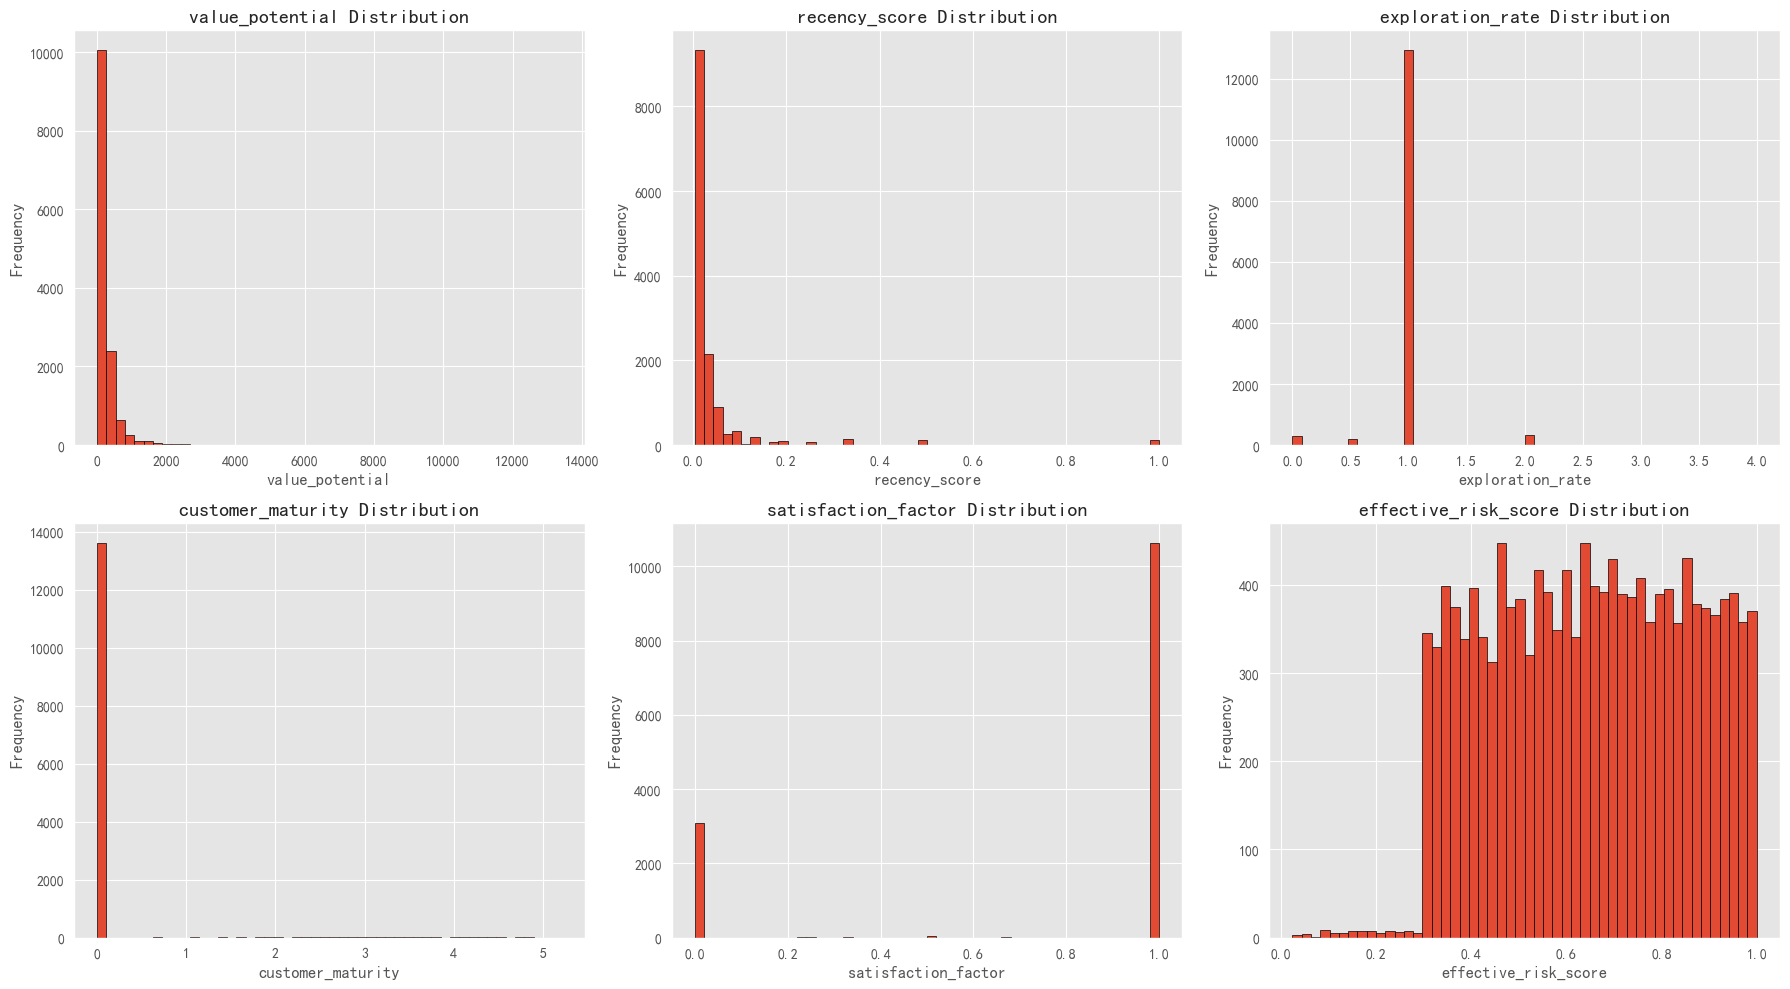

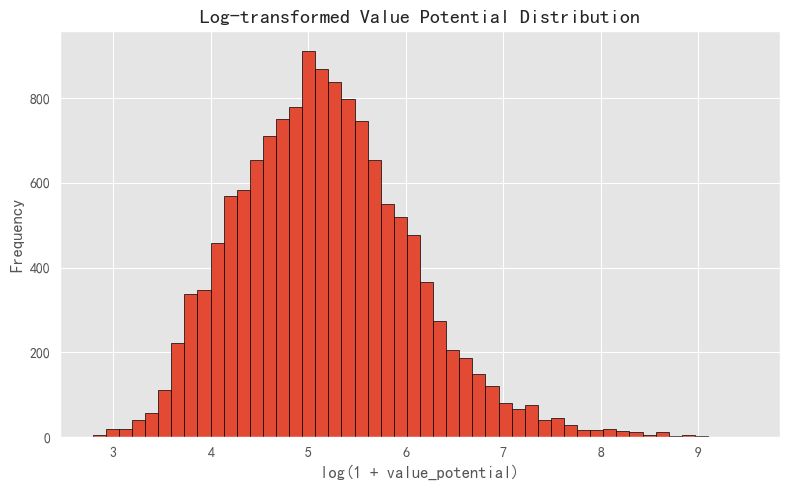

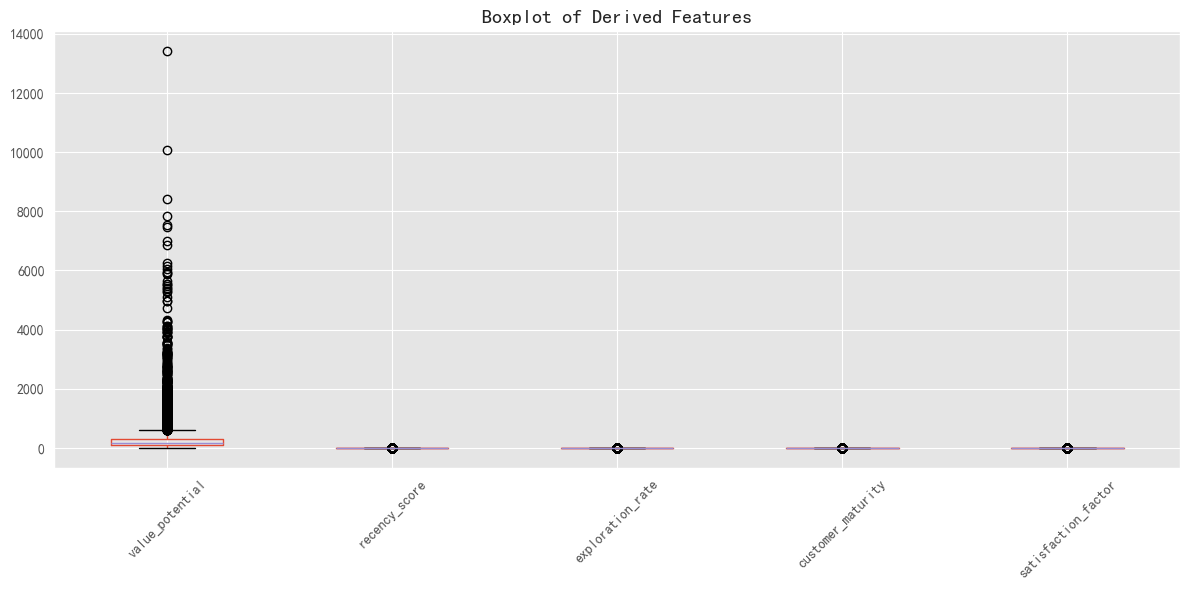

In [34]:
# 2.4 Visualize derived features

import matplotlib.pyplot as plt

plot_cols = [
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor',
    'effective_risk_score'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Visualize log-transformed value potential
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df['value_potential']), bins=50, edgecolor='black')
plt.title('Log-transformed Value Potential Distribution')
plt.xlabel('log(1 + value_potential)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplots for derived features
plt.figure(figsize=(12, 6))
df[[
    'value_potential',
    'recency_score',
    'exploration_rate',
    'customer_maturity',
    'satisfaction_factor'
]].boxplot()
plt.title('Boxplot of Derived Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Check unified risk fields

print("effective_risk_score in df_clean:", 'effective_risk_score' in df_clean.columns)
print("effective_risk_level in df_clean:", 'effective_risk_level' in df_clean.columns)

if 'effective_risk_score' in df_clean.columns:
    print("\nRisk score summary:")
    print(df_clean['effective_risk_score'].describe())

if 'effective_risk_level' in df_clean.columns:
    print("\nRisk level distribution:")
    print(df_clean['effective_risk_level'].value_counts(dropna=False).head(10))

effective_risk_score in df_clean: True
effective_risk_level in df_clean: True

Risk score summary:
count    13763.000000
mean         0.650031
std          0.202277
min          0.024337
25%          0.480938
50%          0.652111
75%          0.821046
max          1.000000
Name: effective_risk_score, dtype: float64

Risk level distribution:
effective_risk_level
Low Risk       4716
High Risk      4558
Medium Risk    4489
Name: count, dtype: int64


## Derived Feature Creation Analysis and Summary

The derived feature creation step was completed successfully, and the new variables have full coverage with no missing values. This means the modeling table is now ready for the next stage of feature selection and model training.

Several derived features show clear behavioral patterns. `value_potential` is strongly right-skewed, with a mean of about 278 but a much lower lower-quartile level, indicating that a small group of customers carries much higher potential value than the majority. `recency_score` remains concentrated at low values, which suggests that only a limited share of customers are very recent under the corrected snapshot definition. `exploration_rate` is highly concentrated around 1, implying that most customers purchased within a narrow category range rather than showing broad exploration. `customer_maturity` is also close to 0 for most customers, which is consistent with a customer base dominated by short observed histories and low repeat behavior. `satisfaction_factor` is mostly close to 1, suggesting that poor service experience is not the dominant constraint in this dataset.

The unified risk signal is now fully available in the modeling table, and its final distribution is relatively balanced across low, medium, and high risk groups. This is useful because it gives the later CLV model a usable risk dimension without depending too heavily on the limited-coverage churn output from Project 06.

Overall, this step improves interpretability, but it also shows a limitation of the underlying business data: many customers still look shallow in depth, narrow in category breadth, and weak in future activity. So feature engineering helps, but it cannot fully remove the structural sparsity of the CLV problem.
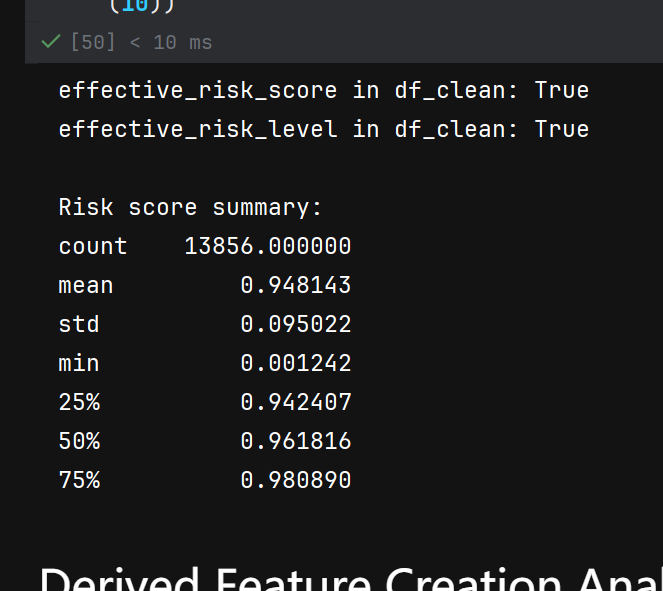

## 3. Target Variable Analysis

This section examines the distribution of future GMV and evaluates whether the prediction target is highly imbalanced or strongly skewed.

Main goals:
- understand the shape of the target variable
- measure the share of zero-GMV customers
- assess concentration among positive-value customers

Because CLV is defined through future spending, the target distribution directly shapes the difficulty of the modeling task. A careful target review is therefore necessary before model training, especially when most customers may contribute no value in the prediction window.

In [36]:
# 3.1 Create output directory

from pathlib import Path
import os

PROJECT_DIR = Path.cwd().parent
OUTPUT_DIR = PROJECT_DIR / 'output' / '07_clv_prediction'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Project directory:", PROJECT_DIR)
print("Output directory:", OUTPUT_DIR)

Current working directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\Statistical_analysis_report
Project directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence
Output directory: C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\07_clv_prediction


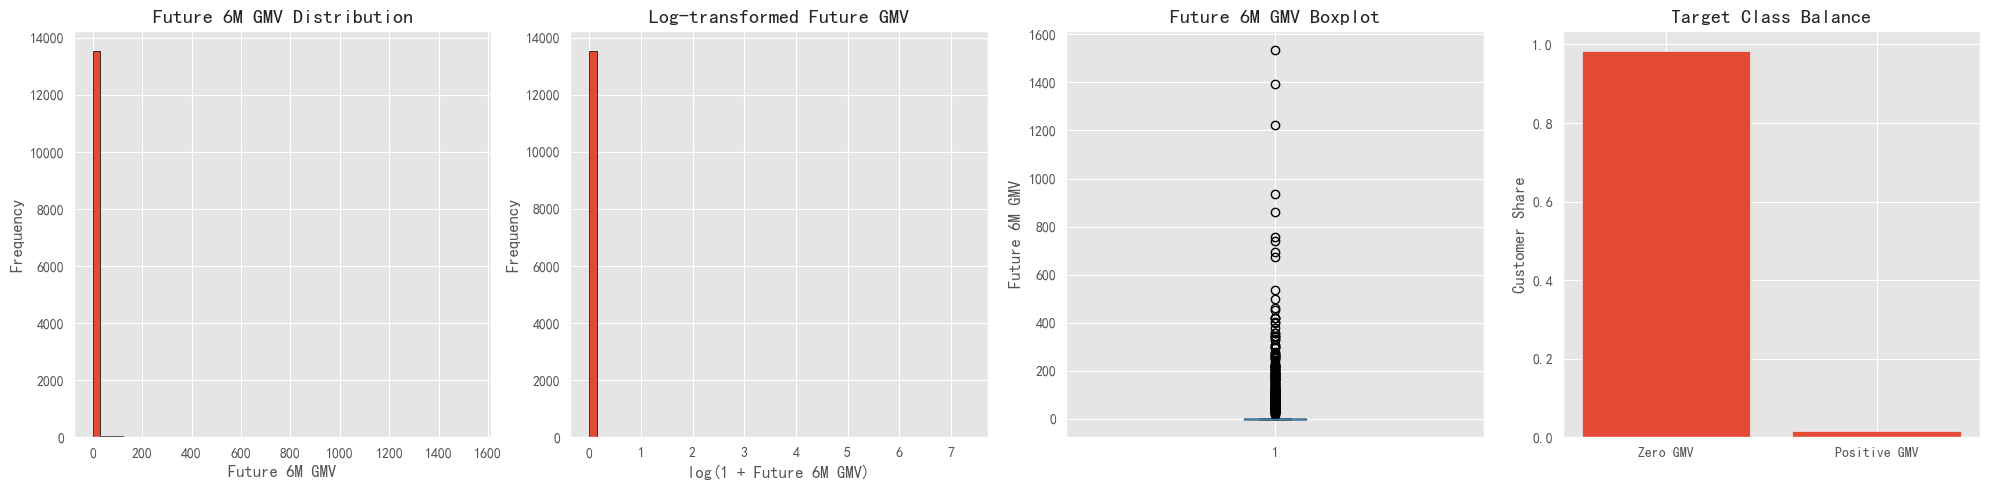

Target variable summary:
count    13763.000000
mean         2.789415
std         33.888546
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       1535.880000
Name: future_6m_gmv, dtype: float64

Zero-GMV customer rate: 98.40%
Positive-GMV customer rate: 1.60%


In [37]:
# 3.2 Visualize future GMV distribution

target_col = 'future_6m_gmv'

zero_rate = (df[target_col] == 0).mean()
active_rate = (df[target_col] > 0).mean()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Raw target distribution
axes[0].hist(df[target_col], bins=50, edgecolor='black')
axes[0].set_title('Future 6M GMV Distribution')
axes[0].set_xlabel('Future 6M GMV')
axes[0].set_ylabel('Frequency')

# Log-transformed target distribution
axes[1].hist(np.log1p(df[target_col]), bins=50, edgecolor='black')
axes[1].set_title('Log-transformed Future GMV')
axes[1].set_xlabel('log(1 + Future 6M GMV)')
axes[1].set_ylabel('Frequency')

# Boxplot
axes[2].boxplot(df[target_col])
axes[2].set_title('Future 6M GMV Boxplot')
axes[2].set_ylabel('Future 6M GMV')

# Zero vs non-zero customers
axes[3].bar(['Zero GMV', 'Positive GMV'], [zero_rate, active_rate])
axes[3].set_title('Target Class Balance')
axes[3].set_ylabel('Customer Share')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'target_distribution.png', dpi=300)
plt.show()

print("Target variable summary:")
print(df[target_col].describe())

print(f"\nZero-GMV customer rate: {zero_rate:.2%}")
print(f"Positive-GMV customer rate: {active_rate:.2%}")

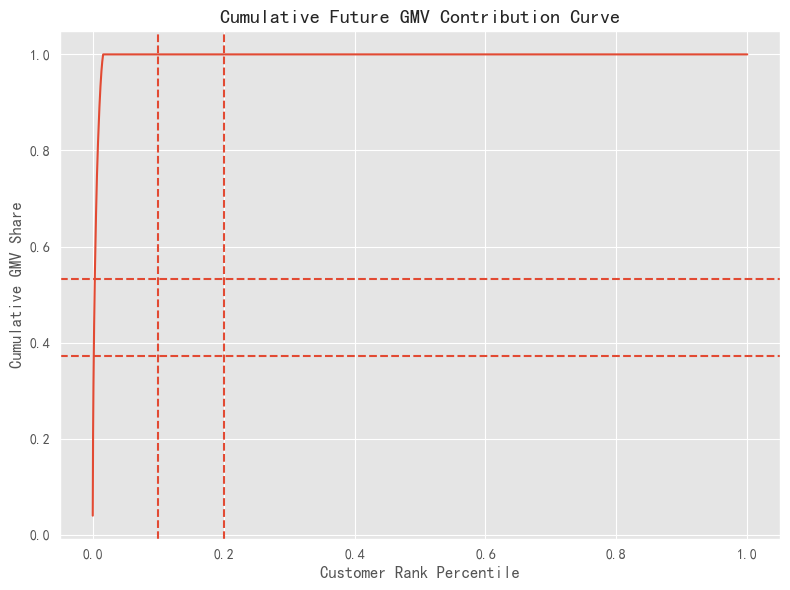

Positive-GMV customer count: 220
Top 10% positive-customer contribution: 37.13%
Top 20% positive-customer contribution: 53.27%


In [38]:
# 3.3 Pareto-style concentration analysis

df_target_sorted = df[['customer_unique_id', target_col]].sort_values(
    target_col,
    ascending=False
).reset_index(drop=True)

df_target_sorted['customer_rank_pct'] = (np.arange(len(df_target_sorted)) + 1) / len(df_target_sorted)

total_target = df_target_sorted[target_col].sum()

if total_target > 0:
    df_target_sorted['cumulative_gmv_pct'] = df_target_sorted[target_col].cumsum() / total_target
else:
    df_target_sorted['cumulative_gmv_pct'] = 0.0

positive_target_df = df_target_sorted[df_target_sorted[target_col] > 0].copy()
positive_customer_count = len(positive_target_df)

if total_target > 0 and positive_customer_count > 0:
    top10_n = max(1, int(positive_customer_count * 0.10))
    top20_n = max(1, int(positive_customer_count * 0.20))
    top10_contribution = positive_target_df.iloc[:top10_n][target_col].sum() / total_target
    top20_contribution = positive_target_df.iloc[:top20_n][target_col].sum() / total_target
else:
    top10_contribution = 0.0
    top20_contribution = 0.0

plt.figure(figsize=(8, 6))
plt.plot(df_target_sorted['customer_rank_pct'], df_target_sorted['cumulative_gmv_pct'])
plt.axvline(0.1, linestyle='--')
plt.axvline(0.2, linestyle='--')
plt.axhline(top10_contribution, linestyle='--')
plt.axhline(top20_contribution, linestyle='--')
plt.xlabel('Customer Rank Percentile')
plt.ylabel('Cumulative GMV Share')
plt.title('Cumulative Future GMV Contribution Curve')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'target_pareto_curve.png', dpi=300)
plt.show()

print(f"Positive-GMV customer count: {positive_customer_count:,}")
print(f"Top 10% positive-customer contribution: {top10_contribution:.2%}")
print(f"Top 20% positive-customer contribution: {top20_contribution:.2%}")


## Target Variable Analysis

The target variable is extremely sparse. The mean future 6-month GMV is only 2.79, while both the median and the 75th percentile are 0. In total, 98.40% of customers generate zero future GMV, and only 1.60% remain positive in the prediction window. This confirms that the CLV task is dominated by inactivity rather than by broad future spending.

Among the 220 positive-GMV customers, value is still concentrated. The top 10% of positive customers contribute 37.13% of future GMV, and the top 20% contribute 53.27%. This shows that even within the active minority, future value is unevenly distributed.

Overall, the target is not only right-skewed but also structurally imbalanced. This matters because a model can appear accurate by predicting low values for most customers while still performing weakly on the small group that drives business value. For that reason, later modeling should be interpreted carefully and not judged only by aggregate error metrics.

## 4. Feature Selection and Modeling Dataset

This section defines the final feature set for CLV prediction and prepares the modeling table for train-test splitting.

Main goals:
- select stable customer-level predictors
- build a clean modeling dataset
- check feature completeness before training

Given the extreme sparsity of the target, feature selection should focus not only on statistical availability but also on business relevance and robustness. In this project, the aim is to retain interpretable features that can support prediction without adding unnecessary noise to an already difficult CLV problem.
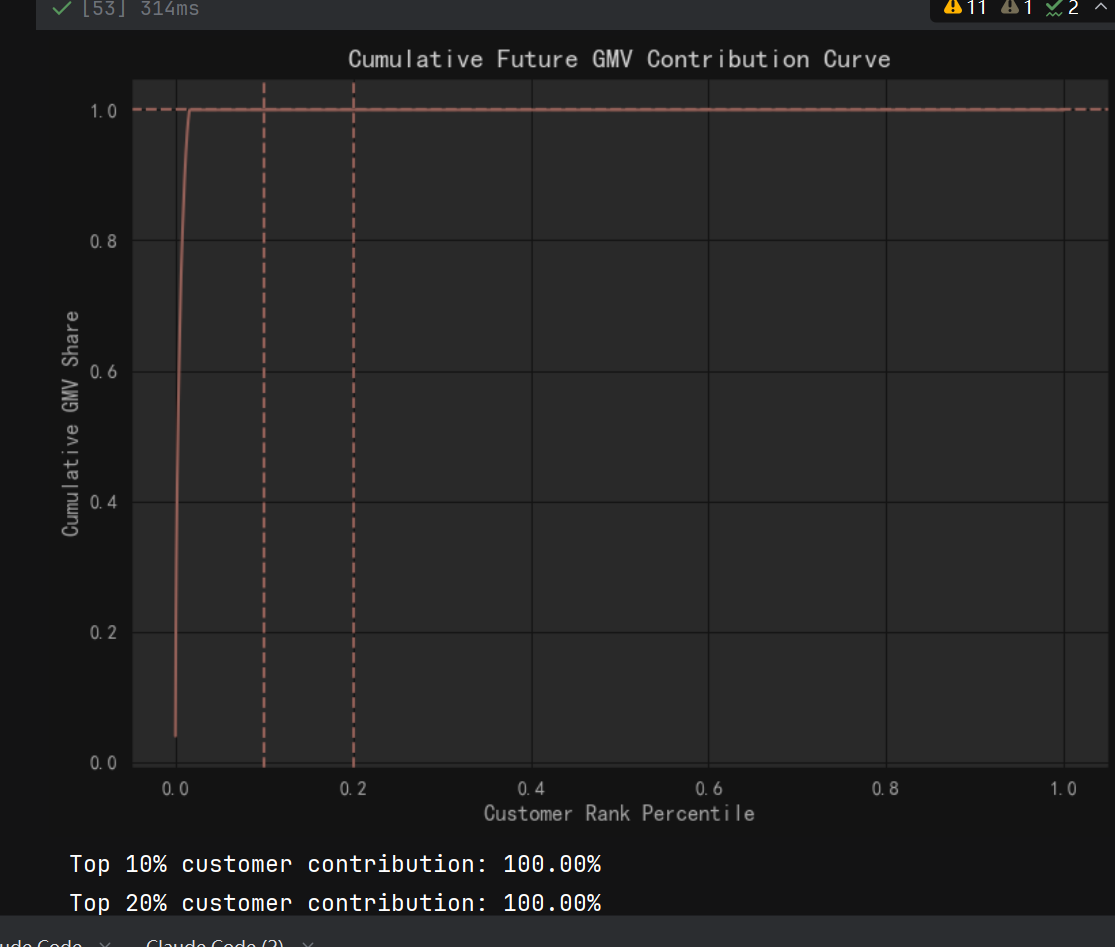
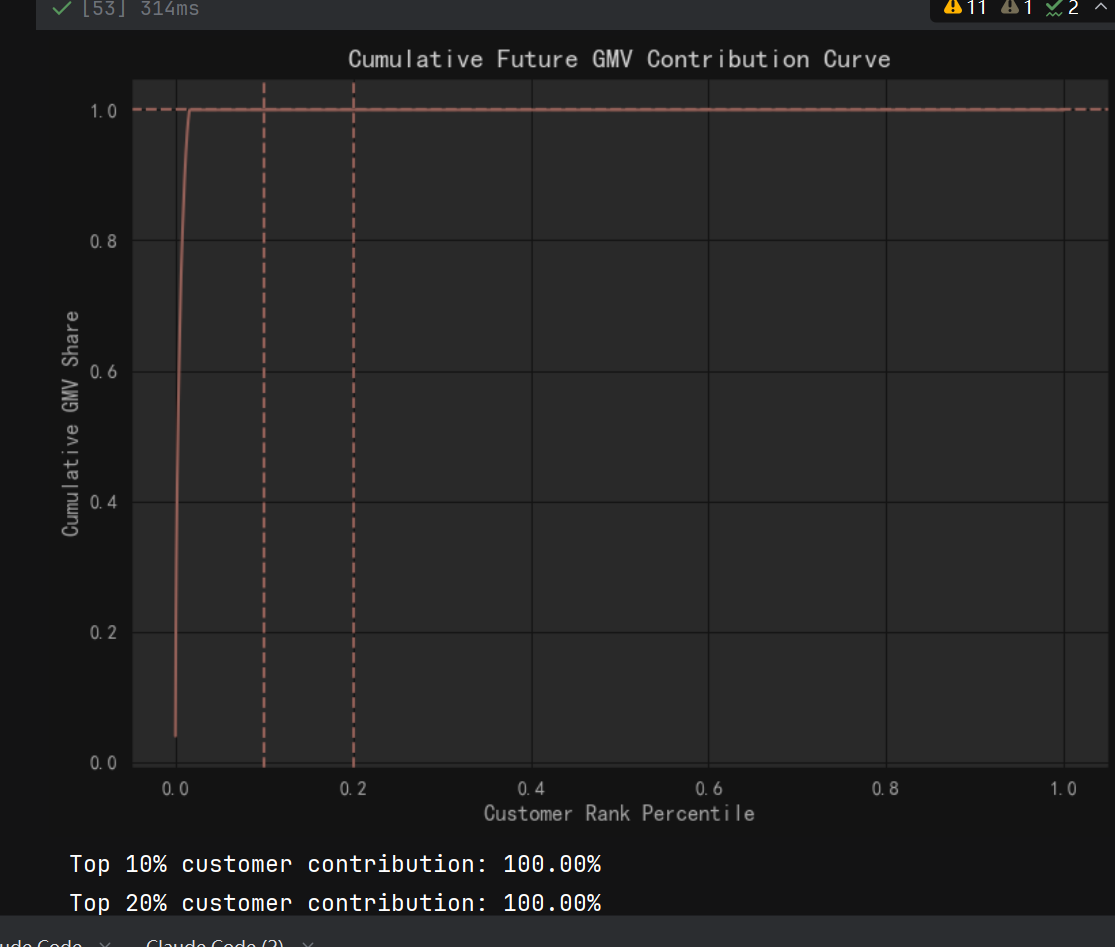

In [39]:
# 4.1 Define feature columns

feature_columns = [
    # RFM features
    'R_score', 'F_score', 'M_score', 'rfm_score',

    # Base transaction features
    'total_orders', 'total_gmv', 'avg_order_value',
    'customer_lifetime_days_snap', 'days_since_last_order_snap', 'monthly_frequency_snap',

    # Product diversity features
    'unique_products_purchased', 'unique_categories_purchased', 'exploration_rate',

    # Satisfaction and delivery features
    'avg_review_score', 'satisfaction_rate', 'bad_review_count',
    'avg_delivery_delay', 'delay_rate', 'satisfaction_factor',

    # Unified risk feature
    'effective_risk_score',

    # Derived features
    'value_potential', 'recency_score', 'customer_maturity',

    # Payment features
    'avg_payment_value', 'max_installments_used'
]

target_column = 'future_6m_gmv'

print("Number of selected features:", len(feature_columns))
print("\nFeature list:")
print(feature_columns)

Number of selected features: 25

Feature list:
['R_score', 'F_score', 'M_score', 'rfm_score', 'total_orders', 'total_gmv', 'avg_order_value', 'customer_lifetime_days_snap', 'days_since_last_order_snap', 'monthly_frequency_snap', 'unique_products_purchased', 'unique_categories_purchased', 'exploration_rate', 'avg_review_score', 'satisfaction_rate', 'bad_review_count', 'avg_delivery_delay', 'delay_rate', 'satisfaction_factor', 'effective_risk_score', 'value_potential', 'recency_score', 'customer_maturity', 'avg_payment_value', 'max_installments_used']


In [40]:
# 4.2 Build modeling dataset

df_model = df.dropna(subset=feature_columns + [target_column]).copy()

X = df_model[feature_columns]
y = df_model[target_column]
y_log = np.log1p(y)

print(f"Modeling dataset shape: {df_model.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nMissing values in selected features:")
print(df_model[feature_columns + [target_column]].isnull().sum().sort_values(ascending=False).head(10))

Modeling dataset shape: (13763, 51)
Feature matrix shape: (13763, 25)
Target shape: (13763,)

Missing values in selected features:
R_score                        0
F_score                        0
M_score                        0
rfm_score                      0
total_orders                   0
total_gmv                      0
avg_order_value                0
customer_lifetime_days_snap    0
days_since_last_order_snap     0
monthly_frequency_snap         0
dtype: int64


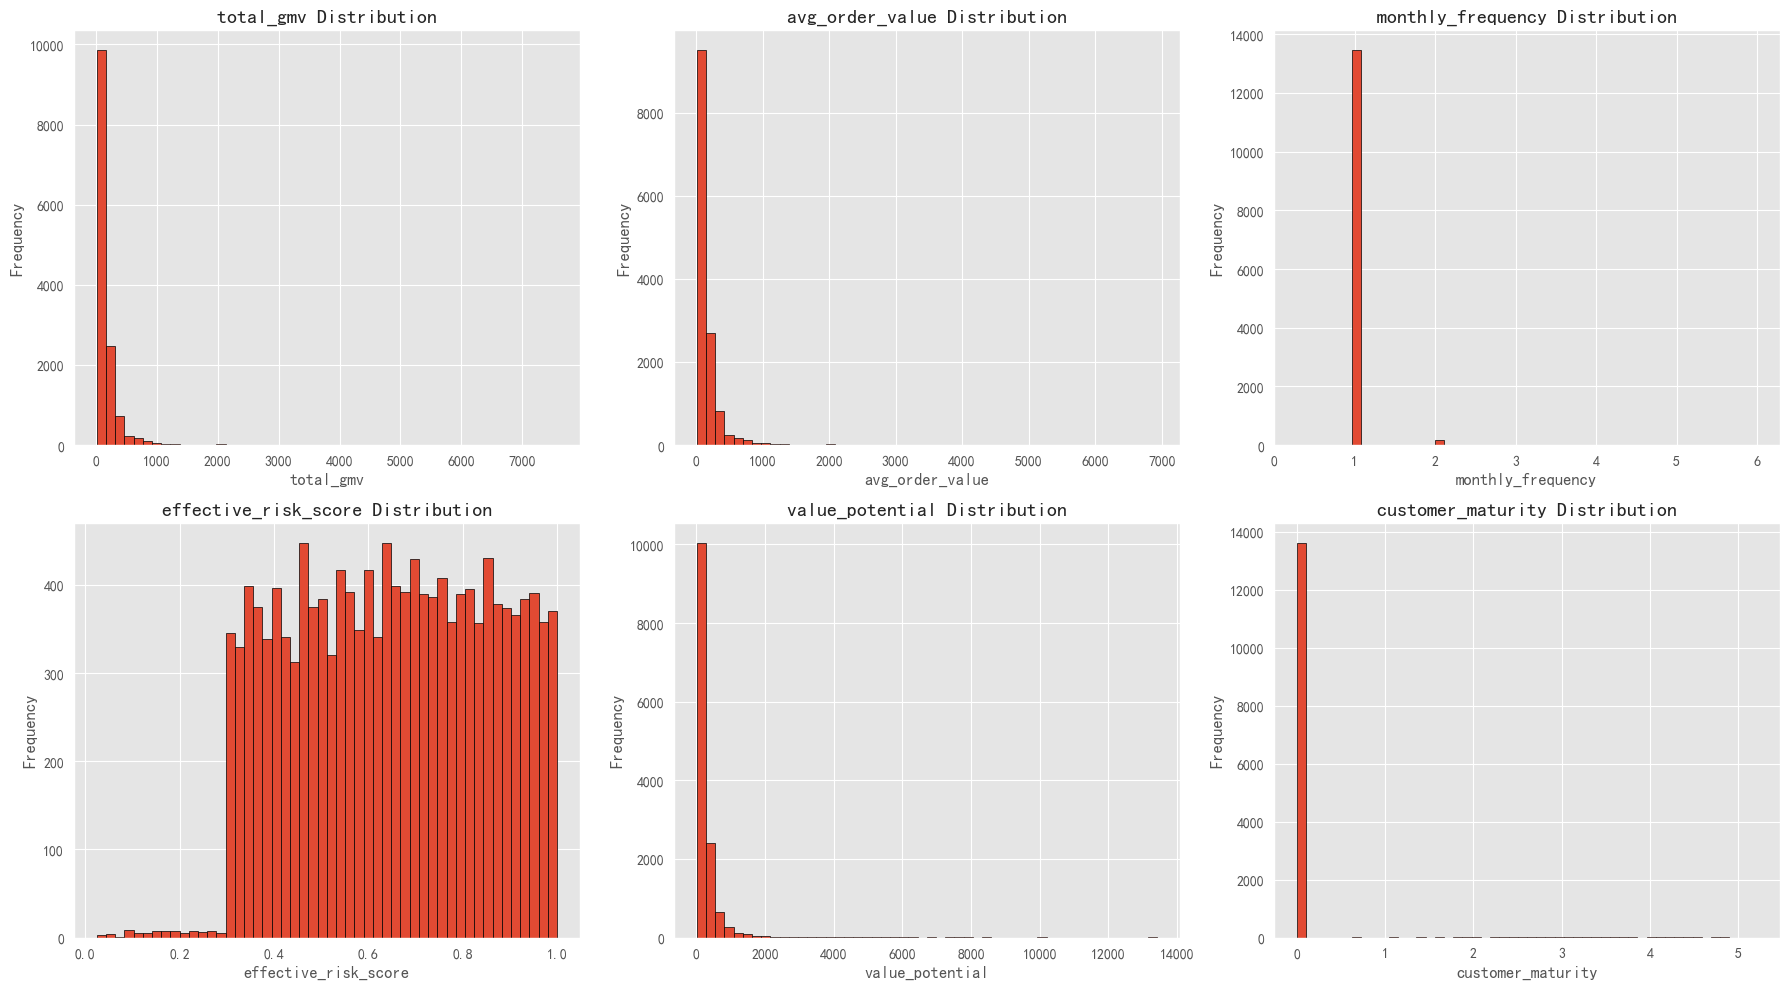

In [41]:
# 4.3 Visualize selected feature distributions

feature_plot_cols = [
    'total_gmv',
    'avg_order_value',
    'monthly_frequency',
    'effective_risk_score',
    'value_potential',
    'customer_maturity'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(feature_plot_cols):
    axes[i].hist(df_model[col], bins=50, edgecolor='black')
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'selected_feature_distributions.png', dpi=300)
plt.show()

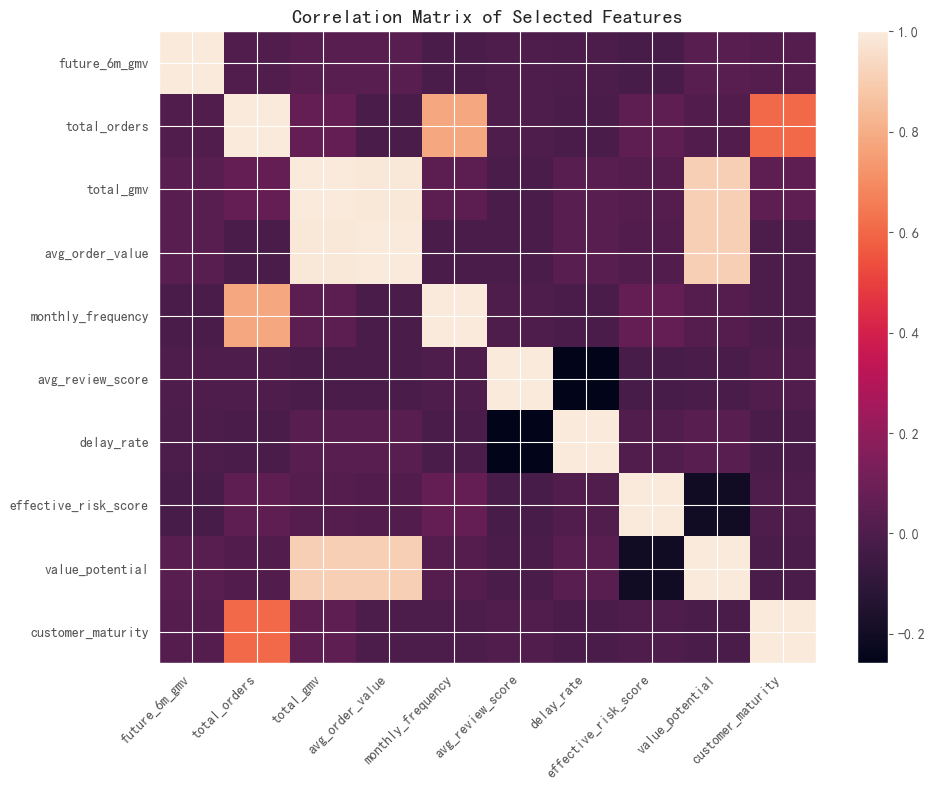

Correlation with target:
future_6m_gmv           1.000000
total_gmv               0.032666
avg_order_value         0.032182
value_potential         0.031666
customer_maturity       0.024487
total_orders            0.009507
avg_review_score        0.005043
delay_rate             -0.005539
monthly_frequency      -0.008555
effective_risk_score   -0.018522
Name: future_6m_gmv, dtype: float64


In [42]:
# 4.4 Correlation check for selected numeric features

corr_cols = [
    'future_6m_gmv',
    'total_orders',
    'total_gmv',
    'avg_order_value',
    'monthly_frequency',
    'avg_review_score',
    'delay_rate',
    'effective_risk_score',
    'value_potential',
    'customer_maturity'
]

corr_matrix = df_model[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation Matrix of Selected Features')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_correlation_matrix.png', dpi=300)
plt.show()

print("Correlation with target:")
print(corr_matrix['future_6m_gmv'].sort_values(ascending=False))

## Model Training and Comparison Analysis and Summary

A total of 25 features were selected, and the final modeling dataset contains 13,763 customers. The feature matrix has shape `(13763, 25)`, and no missing values remain in the selected predictors.

Several important predictors, including `total_gmv`, `avg_order_value`, and `value_potential`, remain strongly right-skewed, while `customer_maturity` is concentrated near zero and `effective_risk_score` is mostly distributed at medium-to-high levels. At the same time, the simple linear correlations with `future_6m_gmv` are all weak, with even the strongest correlations only around 0.03. This suggests that future value is not driven by one dominant linear factor, but by a more complex interaction structure across customer behavior, risk, and value signals.

The train-test split is also stable: the positive-GMV rate remains 1.60% in the full sample, training set, and test set. This is important because it means the later model comparison is not being distorted by an uneven split. Overall, the dataset is ready for training, but the weak marginal correlations already suggest that simple linear modeling may be insufficient for this CLV task.

## 5. Model Training and Comparison

This section trains multiple regression models and compares their performance on the log-transformed CLV target.

The objective is not only to identify the best-performing algorithm, but also to test whether future customer value is better explained by simple linear relationships or by more flexible nonlinear models. Because the target is highly sparse and right-skewed, model comparison is especially important in this project.

In [43]:
# 5.1 Train-test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_model['target_is_positive'] = (df_model[target_column] > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42,
    stratify=df_model['target_is_positive']
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)

print("Train-test split summary:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Positive rate in full data: {df_model['target_is_positive'].mean():.2%}")
print(f"Positive rate in train: {(np.expm1(y_train) > 0).mean():.2%}")
print(f"Positive rate in test: {(np.expm1(y_test) > 0).mean():.2%}")

Train-test split summary:
X_train shape: (11010, 25)
X_test shape: (2753, 25)
Positive rate in full data: 1.60%
Positive rate in train: 1.60%
Positive rate in test: 1.60%


In [44]:
# 5.2 Define evaluation function

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_log_model(y_true_log, y_pred_log, model_name):
    # Evaluate on log scale
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)

    # Convert back to original scale
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 0, None)

    mae_raw = mean_absolute_error(y_true, y_pred)
    rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred))

    result = {
        'Model': model_name,
        'MAE_log': mae_log,
        'RMSE_log': rmse_log,
        'R2_log': r2_log,
        'MAE_raw': mae_raw,
        'RMSE_raw': rmse_raw
    }

    print(f"\n{model_name}")
    print(f"MAE (log):  {mae_log:.4f}")
    print(f"RMSE (log): {rmse_log:.4f}")
    print(f"R² (log):   {r2_log:.4f}")
    print(f"MAE (raw):  {mae_raw:.4f}")
    print(f"RMSE (raw): {rmse_raw:.4f}")

    return result

In [45]:
# 5.2A Baseline model
baseline_pred_log = np.repeat(y_train.mean(), len(y_test))
baseline_result = evaluate_log_model(y_test, baseline_pred_log, "Mean Baseline")


Mean Baseline
MAE (log):  0.1502
RMSE (log): 0.6069
R² (log):   -0.0000
MAE (raw):  2.9568
RMSE (raw): 39.1803


In [46]:
# 5.3 Train models

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

results = [baseline_result]

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
results.append(evaluate_log_model(y_test, y_pred_lr, "Linear Regression"))

# Ridge Regression
ridge_model = Ridge(alpha=10.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)
results.append(evaluate_log_model(y_test, y_pred_ridge, "Ridge Regression"))

# Lasso Regression
lasso_model = Lasso(alpha=0.001, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)
results.append(evaluate_log_model(y_test, y_pred_lasso, "Lasso Regression"))

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
results.append(evaluate_log_model(y_test, y_pred_rf, "Random Forest"))

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
results.append(evaluate_log_model(y_test, y_pred_xgb, "XGBoost"))

# LightGBM
lgb_model = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
results.append(evaluate_log_model(y_test, y_pred_lgb, "LightGBM"))

results_df = pd.DataFrame(results).sort_values('RMSE_log')
print("\nModel comparison:")
print(results_df)

results_df.to_csv(OUTPUT_DIR/'model_comparison_log_target.csv', index=False)


Linear Regression
MAE (log):  0.1323
RMSE (log): 0.4491
R² (log):   0.4523
MAE (raw):  2.8418
RMSE (raw): 38.4774

Ridge Regression
MAE (log):  0.1319
RMSE (log): 0.4494
R² (log):   0.4517
MAE (raw):  2.8426
RMSE (raw): 38.4821

Lasso Regression
MAE (log):  0.1289
RMSE (log): 0.4502
R² (log):   0.4497
MAE (raw):  2.8454
RMSE (raw): 38.4980

Random Forest
MAE (log):  0.0340
RMSE (log): 0.2637
R² (log):   0.8112
MAE (raw):  2.0837
RMSE (raw): 35.4938

XGBoost
MAE (log):  0.0372
RMSE (log): 0.2791
R² (log):   0.7885
MAE (raw):  2.0459
RMSE (raw): 34.9286

LightGBM
MAE (log):  0.0417
RMSE (log): 0.2685
R² (log):   0.8043
MAE (raw):  2.0118
RMSE (raw): 34.9629

Model comparison:
               Model   MAE_log  RMSE_log        R2_log   MAE_raw   RMSE_raw
4      Random Forest  0.033951  0.263725  8.111717e-01  2.083725  35.493779
6           LightGBM  0.041744  0.268511  8.042556e-01  2.011834  34.962902
5            XGBoost  0.037196  0.279119  7.884835e-01  2.045946  34.928602
1  Linear Re

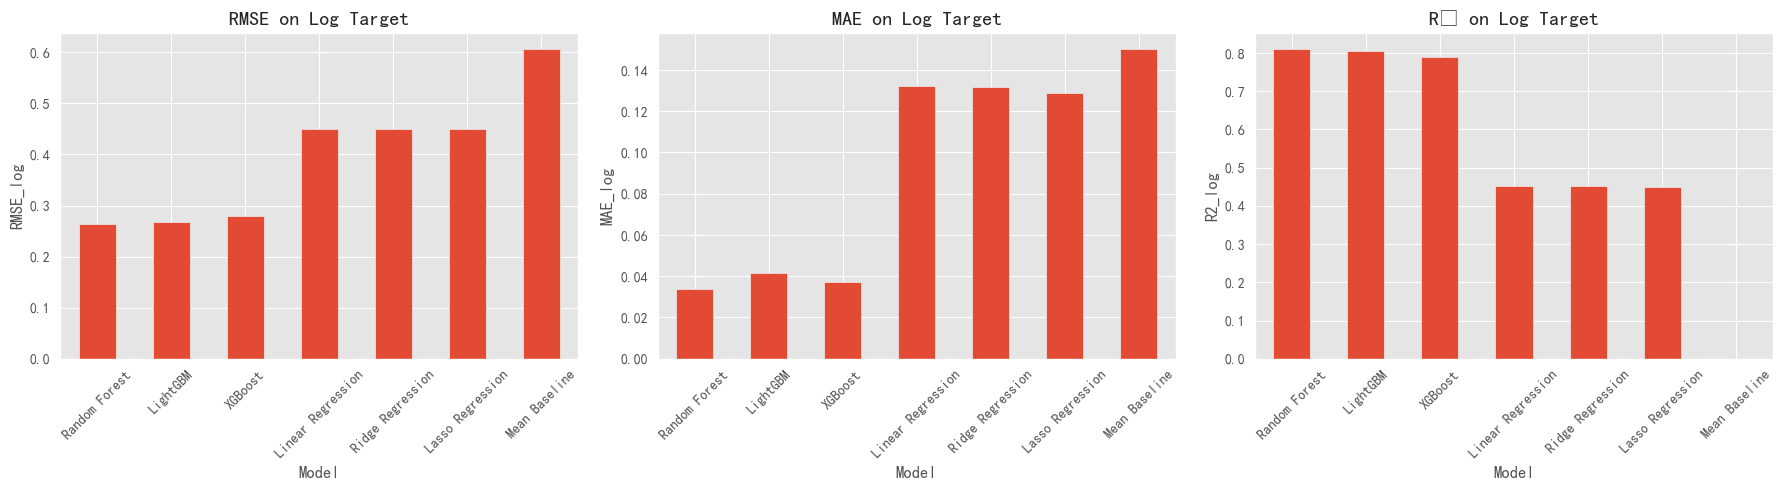

In [47]:
# 5.4 Visualize model comparison

metric_plot_df = results_df.set_index('Model')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metric_plot_df['RMSE_log'].plot(kind='bar', ax=axes[0])
axes[0].set_title('RMSE on Log Target')
axes[0].set_ylabel('RMSE_log')
axes[0].tick_params(axis='x', rotation=45)

metric_plot_df['MAE_log'].plot(kind='bar', ax=axes[1])
axes[1].set_title('MAE on Log Target')
axes[1].set_ylabel('MAE_log')
axes[1].tick_params(axis='x', rotation=45)

metric_plot_df['R2_log'].plot(kind='bar', ax=axes[2])
axes[2].set_title('R² on Log Target')
axes[2].set_ylabel('R2_log')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'model_comparison_log_target.png', dpi=300)
plt.show()

In [48]:
# 5.5 Select best trainable model

# Display full comparison including baseline
results_df = pd.DataFrame(results).sort_values('RMSE_log').reset_index(drop=True)

print("\nModel comparison (including baseline):")
print(results_df)

# Exclude baseline when selecting the best actual model
results_df_models = (
    results_df[results_df['Model'] != 'Mean Baseline']
    .sort_values('RMSE_log')
    .reset_index(drop=True)
)

model_predictions = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression': y_pred_ridge,
    'Lasso Regression': y_pred_lasso,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgb
}

best_model_name = results_df_models.iloc[0]['Model']
best_pred_log = model_predictions[best_model_name]

y_test_raw = np.expm1(y_test)
best_pred_raw = np.expm1(best_pred_log)
best_pred_raw = np.clip(best_pred_raw, 0, None)

print("\nBest trainable model:")
print(best_model_name)

results_df.to_csv(OUTPUT_DIR / 'model_comparison_log_target.csv', index=False)


Model comparison (including baseline):
               Model   MAE_log  RMSE_log        R2_log   MAE_raw   RMSE_raw
0      Random Forest  0.033951  0.263725  8.111717e-01  2.083725  35.493779
1           LightGBM  0.041744  0.268511  8.042556e-01  2.011834  34.962902
2            XGBoost  0.037196  0.279119  7.884835e-01  2.045946  34.928602
3  Linear Regression  0.132267  0.449130  4.523434e-01  2.841807  38.477407
4   Ridge Regression  0.131857  0.449384  4.517229e-01  2.842554  38.482099
5   Lasso Regression  0.128912  0.450207  4.497119e-01  2.845389  38.497965
6      Mean Baseline  0.150228  0.606901 -1.815252e-07  2.956790  39.180253

Best trainable model:
Random Forest


In [49]:
# 5.6 Build holdout evaluation table
df_test_eval = df_model.loc[X_test.index].copy()
df_test_eval['predicted_clv'] = best_pred_raw

print("Holdout evaluation table shape:", df_test_eval.shape)
print(df_test_eval[['customer_unique_id', 'future_6m_gmv', 'predicted_clv']].head())

Holdout evaluation table shape: (2753, 53)
                     customer_unique_id  future_6m_gmv  predicted_clv
3834   46587168f28103639ae8249f19b53043            0.0            0.0
5324   62005030b1a2bad3360ff68271a75edf            0.0            0.0
8218   997bdee4984cf6061062303a6a5f6c97            0.0            0.0
13147  f4e294b108865ee25da71f30a838b8d0            0.0            0.0
2688   31284ff65b82dd9571b788b1c3644fb4            0.0            0.0


## Feature Selection and Modeling Dataset Analysis and Summary

The model comparison shows a clear pattern: tree-based methods perform much better than linear models on this CLV task. Random Forest achieves the best results on the log-transformed target, with `MAE_log = 0.0340`, `RMSE_log = 0.2637`, and `R²_log = 0.8112`, far outperforming the mean baseline and the three linear models. This indicates that customer future value is shaped by nonlinear relationships that linear regression, Ridge, and Lasso cannot capture well.

At the same time, the comparison is not entirely one-sided. LightGBM and XGBoost perform very closely to Random Forest, and they are slightly better on some raw-scale error metrics. This suggests that the three tree-based models are all competitive, while Random Forest is selected here mainly because it gives the strongest overall fit on the transformed target and a stable holdout result.

A useful reflection is that strong model metrics should not be interpreted too quickly as proof that CLV is easy to predict. The target remains extremely zero-heavy, so part of the predictive gain may come from learning the distinction between inactive and positive-value customers rather than precisely estimating the spending of the highest-value group. Even so, the results are strong enough to justify using Random Forest as the primary model for the next steps.

## 6. Best Model Diagnostics

This section evaluates the best-performing model, Random Forest, using prediction and residual diagnostics.

The goal is not only to confirm that the model fits well overall, but also to check where its errors are concentrated. This is especially important in CLV prediction, because strong average performance can still hide weak estimation for the small group of high-value customers.

In [50]:
# 6.1 Set best model outputs

model_objects = {
    'Linear Regression': lr_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

best_model = model_objects[best_model_name]

y_test_raw = np.expm1(y_test)
best_pred_raw = np.expm1(best_pred_log)
best_pred_raw = np.clip(best_pred_raw, 0, None)

residuals_raw = y_test_raw - best_pred_raw
residuals_log = y_test - best_pred_log

print("Best model selected:")
print(best_model_name)

Best model selected:
Random Forest


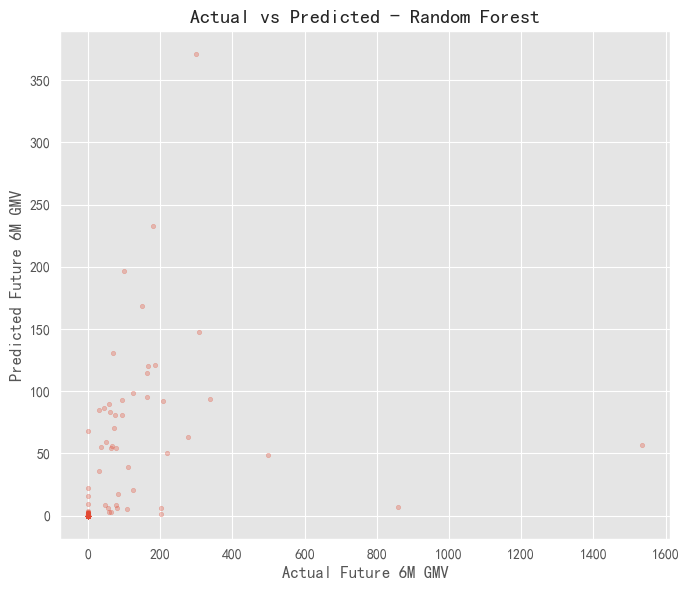

In [51]:
# 6.2 Actual vs predicted

plt.figure(figsize=(7, 6))
plt.scatter(y_test_raw, best_pred_raw, alpha=0.3, s=10)
plt.xlabel('Actual Future 6M GMV')
plt.ylabel('Predicted Future 6M GMV')
plt.title(f'Actual vs Predicted - {best_model_name}')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'best_model_actual_vs_predicted.png', dpi=300)
plt.show()

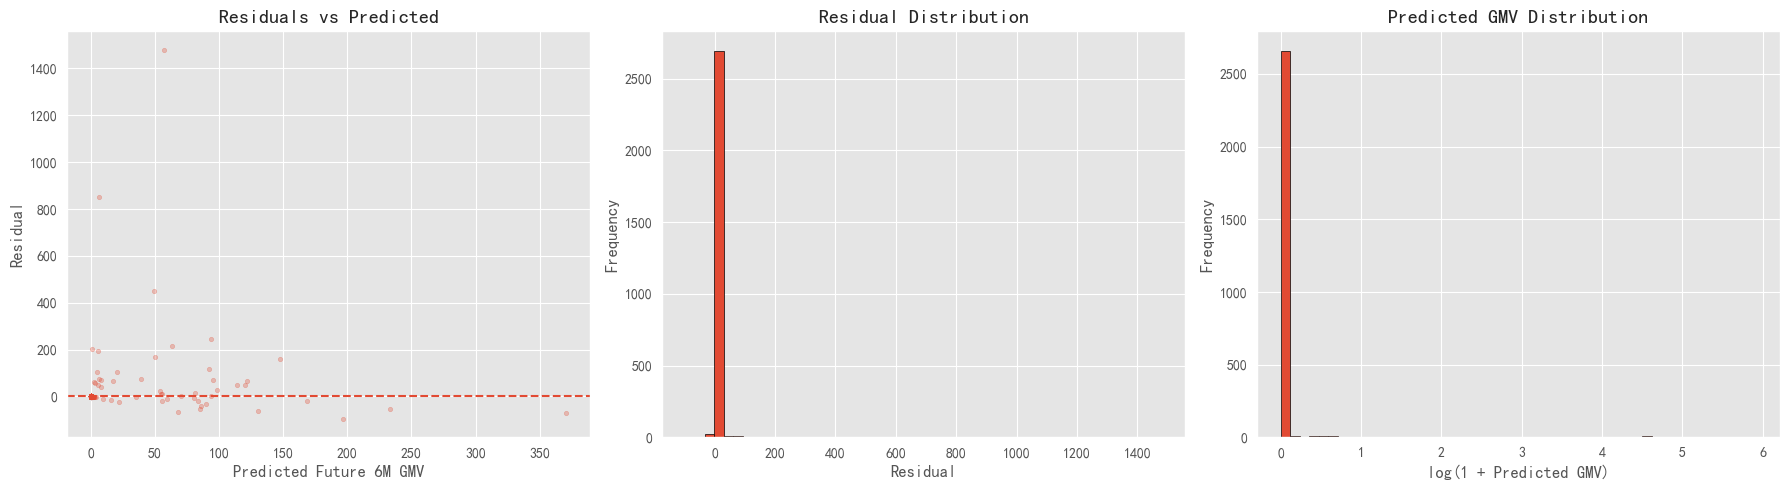

In [52]:
# 6.3 Residual diagnostics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_pred_raw, residuals_raw, alpha=0.3, s=10)
axes[0].axhline(0, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Future 6M GMV')
axes[0].set_ylabel('Residual')

axes[1].hist(residuals_raw, bins=50, edgecolor='black')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

axes[2].hist(np.log1p(best_pred_raw), bins=50, edgecolor='black')
axes[2].set_title('Predicted GMV Distribution')
axes[2].set_xlabel('log(1 + Predicted GMV)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'best_model_residual_diagnostics.png', dpi=300)
plt.show()

## Best Model Diagnostics Analysis and Summary

The Random Forest predictions broadly follow the direction of actual future GMV, which is consistent with its strong overall model performance. However, the scatter plot also shows that the fit is much tighter in the low-value region than in the high-value region. Most customers are clustered near zero, while the few larger-value customers display wider prediction spread.

The residual diagnostics tell a similar story. Residuals are concentrated around small predicted values, but a small number of customers generate very large positive errors. This suggests that the model still struggles to fully capture the upper tail of future GMV. In other words, it is better at learning the general low-value structure of the dataset than at precisely estimating rare high-value outcomes.

This pattern is important for interpretation. A model can still look strong on aggregate metrics while remaining less reliable for the customers who matter most commercially. So the diagnostics support using Random Forest as the best overall model, but they also suggest that high-value customer prediction remains the hardest part of the task.

## 7. Feature Importance

This section identifies the most important predictors in the best-performing CLV model.
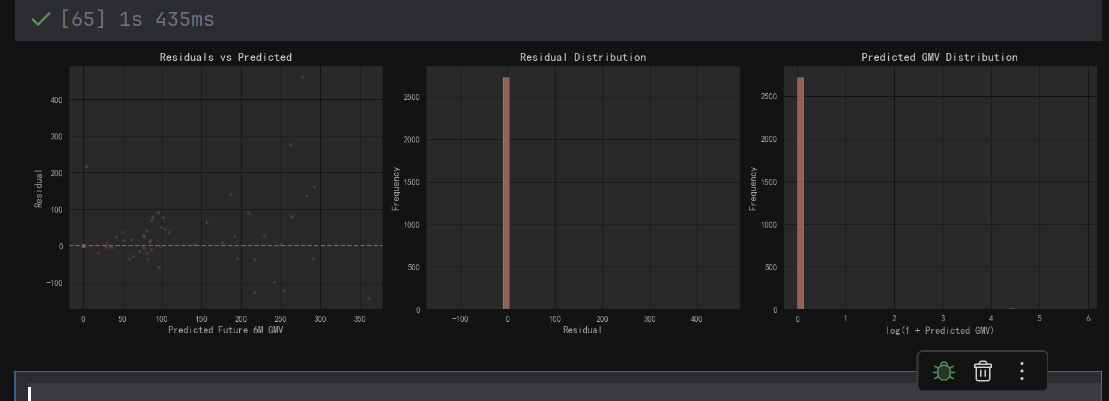
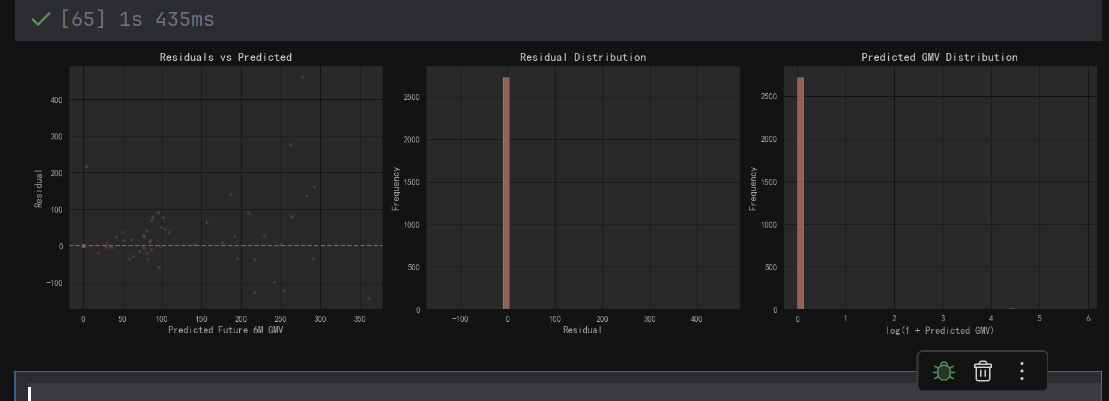
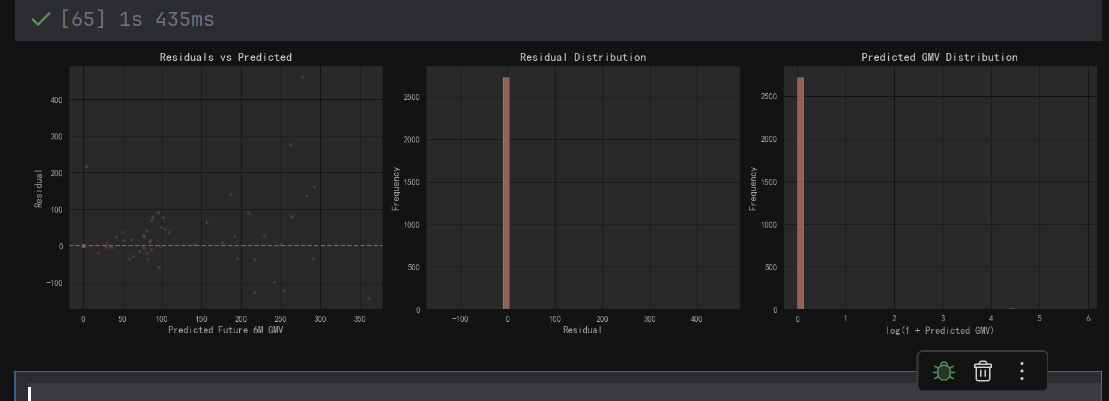

In [53]:
# 7.1 Extract feature importance from Random Forest

feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 feature importance:")
print(feature_importance.head(15))

feature_importance.to_csv(
    OUTPUT_DIR/'feature_importance_rf.csv',
    index=False
)

Top 15 feature importance:
                       feature  importance
0                      R_score    0.629908
4                 total_orders    0.057348
1                      F_score    0.055767
12            exploration_rate    0.049774
10   unique_products_purchased    0.033562
19        effective_risk_score    0.031725
3                    rfm_score    0.022220
20             value_potential    0.020306
5                    total_gmv    0.017947
16          avg_delivery_delay    0.015688
21               recency_score    0.012116
8   days_since_last_order_snap    0.009752
23           avg_payment_value    0.009013
24       max_installments_used    0.008620
6              avg_order_value    0.008346


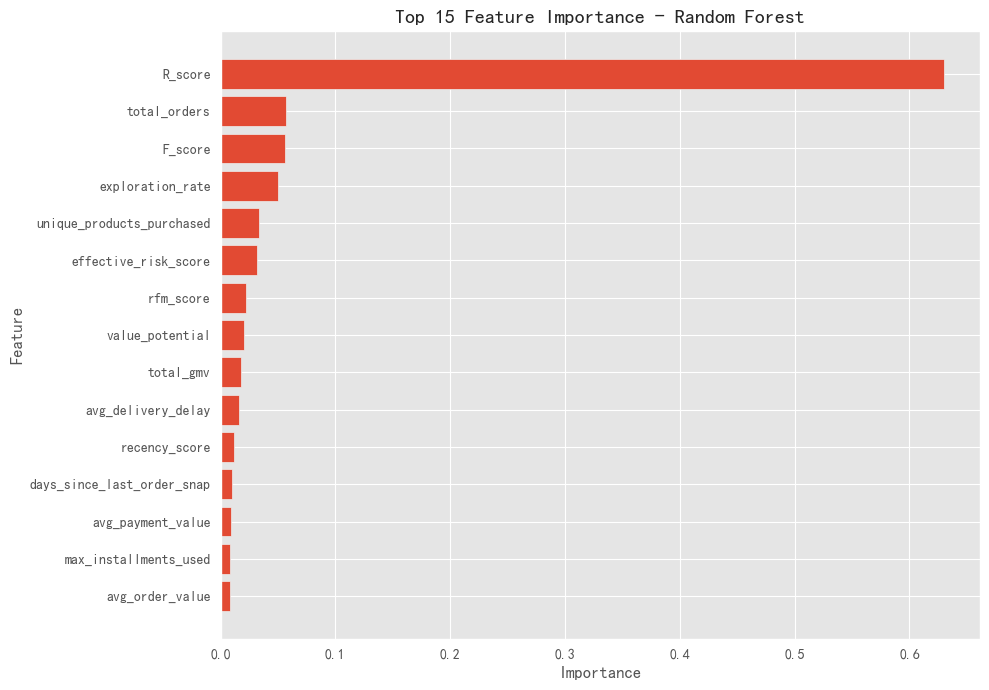

In [54]:
# 7.2 Plot top 15 feature importance

top_n = 15
top_features = feature_importance.head(top_n).sort_values('importance')

plt.figure(figsize=(10, 7))
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Top {top_n} Feature Importance - Random Forest')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_importance_top15_rf.png', dpi=300)
plt.show()

In [55]:
# 7.3 Permutation importance on holdout set
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': perm_result.importances_mean
}).sort_values('importance', ascending=False)

print("Top 15 permutation importance:")
print(perm_importance.head(15))

perm_importance.to_csv(
    OUTPUT_DIR / 'feature_importance_permutation.csv',
    index=False
)

Top 15 permutation importance:
                       feature  importance
0                      R_score    0.889460
4                 total_orders    0.577285
3                    rfm_score    0.308024
1                      F_score    0.270584
19        effective_risk_score    0.131737
12            exploration_rate    0.121270
10   unique_products_purchased    0.044063
8   days_since_last_order_snap    0.032352
5                    total_gmv    0.019264
21               recency_score    0.014929
2                      M_score    0.012086
16          avg_delivery_delay    0.004644
24       max_installments_used    0.004211
6              avg_order_value    0.001507
20             value_potential    0.001106


## Feature Importance Analysis

Feature importance is highly concentrated in RFM and recency-related signals. `R_score` is the dominant predictor by a large margin, while `total_orders`, `F_score`, `rfm_score`, and `days_since_last_order_snap` also contribute to the model.

Other variables, such as `effective_risk_score`, `exploration_rate`, `value_potential`, and `total_gmv`, still add information but play a smaller role. This suggests that future GMV in this dataset is driven more by recent customer activity and behavioral position than by any single spending variable alone.

## 8. CLV Prediction and Customer Tiering

This section uses the best model to predict customer CLV and assign customers into value tiers.

The purpose is not only to generate individual CLV estimates, but also to translate model outputs into a tier structure that can support later business segmentation and resource allocation.

In [56]:
# 8.1 Score all modelable customers

X_all = df_model[feature_columns].copy()

# Random Forest was trained on the original feature scale
predicted_log_clv = best_model.predict(X_all)
predicted_clv = np.expm1(predicted_log_clv)
predicted_clv = np.clip(predicted_clv, 0, None)

df_model['predicted_clv'] = predicted_clv

print("Prediction summary:")
print(df_model['predicted_clv'].describe())

Prediction summary:
count    13763.000000
mean         1.544637
std         16.761546
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        461.143959
Name: predicted_clv, dtype: float64


In [57]:
# 8.2 Create customer value tiers

df_model['value_tier'] = 'Bronze'

positive_mask = df_model['predicted_clv'] > 0
df_positive = df_model.loc[positive_mask, ['customer_unique_id', 'predicted_clv']].copy()

if len(df_positive) > 0:
    df_positive['positive_percentile'] = df_positive['predicted_clv'].rank(
        method='first',
        pct=True
    )

    def assign_positive_tier(percentile):
        if percentile >= 0.80:
            return 'Platinum'
        elif percentile >= 0.50:
            return 'Gold'
        else:
            return 'Silver'

    df_positive['value_tier'] = df_positive['positive_percentile'].apply(assign_positive_tier)

    df_model = df_model.drop(columns=['value_tier'], errors='ignore').merge(
        df_positive[['customer_unique_id', 'value_tier']],
        on='customer_unique_id',
        how='left'
    )

    df_model['value_tier'] = df_model['value_tier'].fillna('Bronze')

print("Tier distribution:")
print(df_model['value_tier'].value_counts())

Tier distribution:
value_tier
Bronze      13140
Silver        311
Gold          187
Platinum      125
Name: count, dtype: int64


In [58]:
# 8.3 Summarize tier statistics

tier_stats = df_model.groupby('value_tier').agg({
    'customer_unique_id': 'count',
    'predicted_clv': ['mean', 'median', 'sum'],
    'future_6m_gmv': ['mean', 'median', 'sum']
}).round(2)

tier_stats.columns = [
    'customer_count',
    'predicted_clv_mean', 'predicted_clv_median', 'predicted_clv_sum',
    'actual_gmv_mean', 'actual_gmv_median', 'actual_gmv_sum'
]

tier_stats = tier_stats.sort_values('predicted_clv_mean', ascending=False)

print("Tier statistics:")
print(tier_stats)

tier_stats.to_csv(OUTPUT_DIR/'customer_tier_statistics.csv')

Tier statistics:
            customer_count  predicted_clv_mean  predicted_clv_median  \
value_tier                                                             
Platinum               125              146.29                113.99   
Gold                   187               15.56                  5.67   
Silver                 311                0.20                  0.10   
Bronze               13140                0.00                  0.00   

            predicted_clv_sum  actual_gmv_mean  actual_gmv_median  \
value_tier                                                          
Platinum             18286.61           198.10             133.18   
Gold                  2909.35            72.88              22.78   
Silver                  62.88             0.00               0.00   
Bronze                   0.00             0.00               0.00   

            actual_gmv_sum  
value_tier                  
Platinum          24762.12  
Gold              13628.60  
Silver             

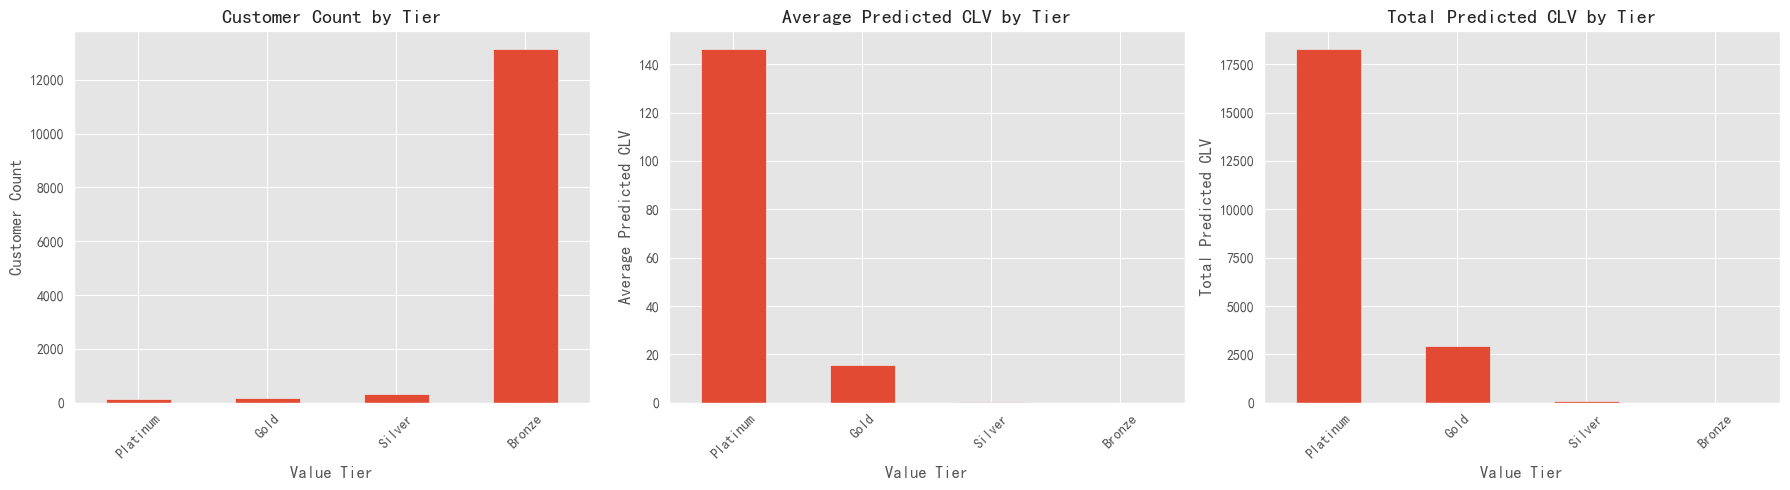

In [59]:
# 8.4 Visualize customer tiers

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Customer count by tier
tier_stats['customer_count'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Customer Count by Tier')
axes[0].set_xlabel('Value Tier')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=45)

# Average predicted CLV by tier
tier_stats['predicted_clv_mean'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Average Predicted CLV by Tier')
axes[1].set_xlabel('Value Tier')
axes[1].set_ylabel('Average Predicted CLV')
axes[1].tick_params(axis='x', rotation=45)

# Total predicted CLV by tier
tier_stats['predicted_clv_sum'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Total Predicted CLV by Tier')
axes[2].set_xlabel('Value Tier')
axes[2].set_ylabel('Total Predicted CLV')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR/'customer_tier_overview.png', dpi=300)
plt.show()

In [60]:
# 8.5 Export customer tier results

tier_output_cols = [
    'customer_unique_id',
    'predicted_clv',
    'value_tier',
    'future_6m_gmv',
    'effective_risk_score',
    'effective_risk_level'
]

df_model[tier_output_cols].to_csv(
    OUTPUT_DIR/'customer_value_tiers.csv',
    index=False
)

print("Customer tier file saved.")

Customer tier file saved.


## CLV Prediction and Customer Tiering Analysis and Summary

The predicted CLV distribution remains highly sparse. The mean predicted CLV is 1.54, while the median and the 75th percentile are both 0, showing that most customers are still predicted to generate no future value. This means the model output is concentrated in a very small minority of higher-value customers.

To make the tiering more interpretable, customers with predicted CLV equal to 0 were assigned directly to Bronze, and only positive-value customers were split into Silver, Gold, and Platinum. Under this revised logic, Bronze contains 13,140 customers, while Silver, Gold, and Platinum contain 311, 187, and 125 customers respectively. This produces a much clearer value hierarchy than a direct percentile split over the full population.

The resulting tier statistics are also meaningful. Platinum has by far the highest average predicted CLV and the highest actual future GMV, followed by Gold, while Silver and Bronze contribute little or no realised value. This suggests that the revised tiering approach is broadly aligned with actual value concentration.

At the same time, this result also reveals a limitation of the dataset: the customer base is dominated by zero-value cases, so the tier structure is driven as much by inactivity filtering as by fine-grained value differences. In other words, the model is effective at separating non-value from potential value, but the distinction within the positive-value minority remains a more difficult task.
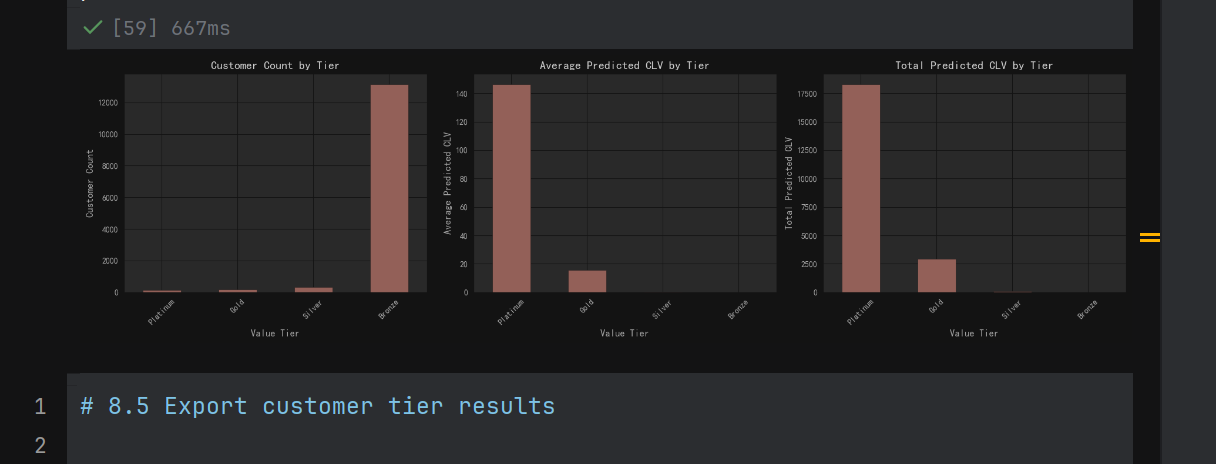

## 9. Value-Risk Matrix

This section combines predicted customer value and customer risk to build a value-risk matrix for segmentation.

The aim is to move from pure prediction to action by identifying which customer groups should be retained, protected, nurtured, or deprioritized.

In [61]:
# 9.1 Create value-risk labels

df_model['clv_group'] = df_model['value_tier'].map({
    'Platinum': 'High CLV',
    'Gold': 'High CLV',
    'Silver': 'Low CLV',
    'Bronze': 'Low CLV'
})

df_model['risk_group'] = np.where(
    df_model['effective_risk_level'].isin(['High Risk']),
    'High Risk',
    'Low/Medium Risk'
)

print("CLV group distribution:")
print(df_model['clv_group'].value_counts())

print("\nRisk group distribution:")
print(df_model['risk_group'].value_counts())

CLV group distribution:
clv_group
Low CLV     13451
High CLV      312
Name: count, dtype: int64

Risk group distribution:
risk_group
Low/Medium Risk    9205
High Risk          4558
Name: count, dtype: int64


In [62]:
# 9.2 Build value-risk matrix

value_risk_matrix = pd.crosstab(
    df_model['clv_group'],
    df_model['risk_group']
)

print("Value-risk matrix:")
print(value_risk_matrix)

value_risk_matrix.to_csv(
    OUTPUT_DIR/'value_risk_matrix_counts.csv'
)

Value-risk matrix:
risk_group  High Risk  Low/Medium Risk
clv_group                             
High CLV           43              269
Low CLV          4515             8936


In [63]:
# 9.3 Assign strategy quadrants

def assign_strategy(row):
    if row['clv_group'] == 'High CLV' and row['risk_group'] == 'Low/Medium Risk':
        return 'Protect'
    elif row['clv_group'] == 'High CLV' and row['risk_group'] == 'High Risk':
        return 'Retain'
    elif row['clv_group'] == 'Low CLV' and row['risk_group'] == 'Low/Medium Risk':
        return 'Nurture'
    else:
        return 'Low Priority'

df_model['strategy_quadrant'] = df_model.apply(assign_strategy, axis=1)

print("Strategy quadrant distribution:")
print(df_model['strategy_quadrant'].value_counts())

Strategy quadrant distribution:
strategy_quadrant
Nurture         8936
Low Priority    4515
Protect          269
Retain            43
Name: count, dtype: int64


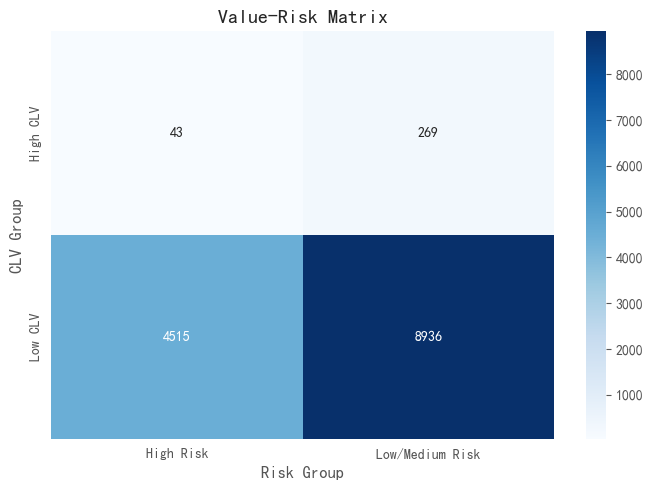

In [64]:
# 9.4 Visualize value-risk matrix

import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(value_risk_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Value-Risk Matrix')
plt.xlabel('Risk Group')
plt.ylabel('CLV Group')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'value_risk_matrix_heatmap.png', dpi=300)
plt.show()

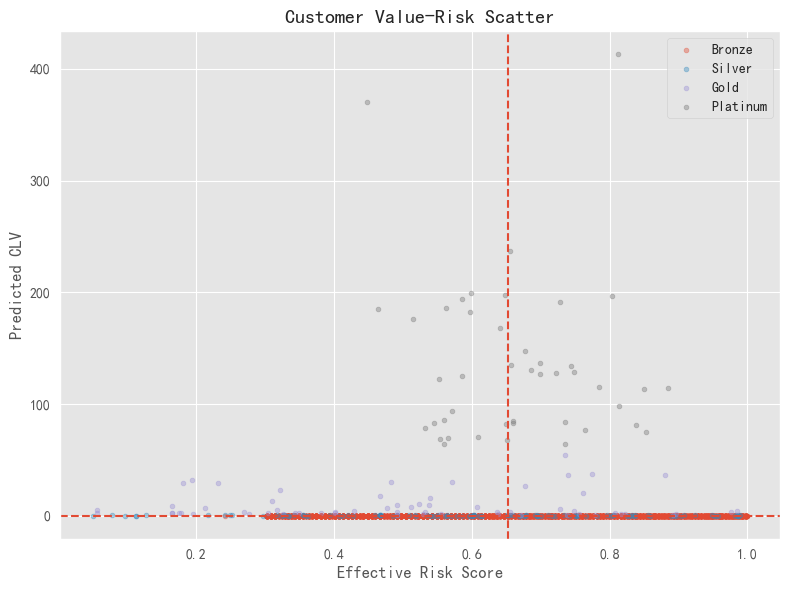

In [65]:
# 9.5 Visualize customer value vs risk

plot_df = df_model.copy()

# Sample for visualization if needed
if len(plot_df) > 5000:
    plot_df = plot_df.sample(5000, random_state=42)

plt.figure(figsize=(8, 6))
for tier in ['Bronze', 'Silver', 'Gold', 'Platinum']:
    subset = plot_df[plot_df['value_tier'] == tier]
    plt.scatter(
        subset['effective_risk_score'],
        subset['predicted_clv'],
        alpha=0.4,
        s=12,
        label=tier
    )

plt.axvline(
    df_model['effective_risk_score'].median(),
    linestyle='--'
)
plt.axhline(
    df_model['predicted_clv'].median(),
    linestyle='--'
)

plt.xlabel('Effective Risk Score')
plt.ylabel('Predicted CLV')
plt.title('Customer Value-Risk Scatter')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'value_risk_scatter.png', dpi=300)
plt.show()

In [66]:
# 9.6 Summarize strategy groups

strategy_summary = df_model.groupby('strategy_quadrant').agg({
    'customer_unique_id': 'count',
    'predicted_clv': ['mean', 'sum'],
    'future_6m_gmv': ['mean', 'sum'],
    'effective_risk_score': 'mean'
}).round(2)

strategy_summary.columns = [
    'customer_count',
    'predicted_clv_mean', 'predicted_clv_sum',
    'actual_gmv_mean', 'actual_gmv_sum',
    'risk_score_mean'
]

strategy_summary = strategy_summary.sort_values('predicted_clv_sum', ascending=False)

print("Strategy summary:")
print(strategy_summary)

strategy_summary.to_csv(
    OUTPUT_DIR/'strategy_quadrant_summary.csv'
)

Strategy summary:
                   customer_count  predicted_clv_mean  predicted_clv_sum  \
strategy_quadrant                                                          
Protect                       269               67.64           18195.14   
Retain                         43               69.79            3000.81   
Nurture                      8936                0.01              45.73   
Low Priority                 4515                0.00              17.15   

                   actual_gmv_mean  actual_gmv_sum  risk_score_mean  
strategy_quadrant                                                    
Protect                     120.92        32528.06             0.53  
Retain                      136.34         5862.66             0.82  
Nurture                       0.00            0.00             0.54  
Low Priority                  0.00            0.00             0.88  


## Value-Risk Matrix Analysis

The value-risk matrix is highly imbalanced. Most customers fall into the low-value side of the portfolio: 8,936 are in `Nurture` and 4,515 are in `Low Priority`. This shows that the customer base is dominated by low-CLV customers, although their risk levels are not identical.

The two high-value groups are much smaller. `Protect` contains 269 customers with high CLV and lower risk, while `Retain` contains only 43 customers with high CLV and high risk. Although small, these groups are the most strategically important because they are more likely to drive future value.

This result is useful but also revealing. The matrix helps prioritize action, yet it also shows that most of the portfolio has limited immediate value. In other words, segmentation is not only identifying the best customers; it is also confirming how concentrated future value is in a very small minority.

## 10. Marketing Budget Allocation

This section allocates marketing budget based on predicted CLV and strategy priority.

In [67]:
# 10.1 Set total budget and strategy weights

total_budget = 1_000_000

strategy_weights = {
    'Protect': 1.2,
    'Retain': 1.5,
    'Nurture': 0.8,
    'Low Priority': 0.3
}

df_model['strategy_weight'] = df_model['strategy_quadrant'].map(strategy_weights)
df_model['weighted_clv'] = df_model['predicted_clv'] * df_model['strategy_weight']

print("Strategy weights applied:")
print(df_model[['strategy_quadrant', 'strategy_weight']].drop_duplicates().sort_values('strategy_weight', ascending=False))

Strategy weights applied:
    strategy_quadrant  strategy_weight
583            Retain              1.5
94            Protect              1.2
3             Nurture              0.8
0        Low Priority              0.3


In [68]:
# 10.2 Allocate customer-level budget

weighted_total = df_model['weighted_clv'].sum()

if weighted_total == 0:
    df_model['budget_share'] = 1 / len(df_model)
else:
    df_model['budget_share'] = df_model['weighted_clv'] / weighted_total

df_model['allocated_budget'] = df_model['budget_share'] * total_budget

print("Budget allocation summary:")
print(df_model['allocated_budget'].describe())

Budget allocation summary:
count    13763.000000
mean        72.658577
std        788.340580
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      23480.762502
Name: allocated_budget, dtype: float64


In [69]:
# 10.3 Summarize budget by strategy quadrant

budget_summary = df_model.groupby('strategy_quadrant').agg({
    'customer_unique_id': 'count',
    'allocated_budget': ['sum', 'mean'],
    'predicted_clv': ['sum', 'mean'],
    'future_6m_gmv': ['sum', 'mean']
}).round(2)

budget_summary.columns = [
    'customer_count',
    'budget_sum', 'budget_mean',
    'predicted_clv_sum', 'predicted_clv_mean',
    'actual_gmv_sum', 'actual_gmv_mean'
]

budget_summary['backtest_gmv_per_budget'] = (
    budget_summary['actual_gmv_sum'] / budget_summary['budget_sum']
).replace([np.inf, -np.inf], np.nan).round(2)

budget_summary = budget_summary.sort_values('budget_sum', ascending=False)

print("Budget summary by strategy:")
print(budget_summary)

budget_summary.to_csv(
    OUTPUT_DIR/'budget_allocation_by_strategy.csv'
)

Budget summary by strategy:
                   customer_count  budget_sum  budget_mean  predicted_clv_sum  \
strategy_quadrant                                                               
Protect                       269   827769.24      3077.21           18195.14   
Retain                         43   170648.65      3968.57            3000.81   
Nurture                      8936     1387.04         0.16              45.73   
Low Priority                 4515      195.08         0.04              17.15   

                   predicted_clv_mean  actual_gmv_sum  actual_gmv_mean  \
strategy_quadrant                                                        
Protect                         67.64        32528.06           120.92   
Retain                          69.79         5862.66           136.34   
Nurture                          0.01            0.00             0.00   
Low Priority                     0.00            0.00             0.00   

                   backtest_gmv_per_budg

In [70]:
# 10.4 Summarize budget by value tier

budget_by_tier = df_model.groupby('value_tier').agg({
    'customer_unique_id': 'count',
    'allocated_budget': ['sum', 'mean'],
    'predicted_clv': ['sum', 'mean']
}).round(2)

budget_by_tier.columns = [
    'customer_count',
    'budget_sum', 'budget_mean',
    'predicted_clv_sum', 'predicted_clv_mean'
]

budget_by_tier = budget_by_tier.sort_values('budget_sum', ascending=False)

print("Budget summary by tier:")
print(budget_by_tier)

budget_by_tier.to_csv(
    OUTPUT_DIR/'budget_allocation_by_tier.csv'
)

Budget summary by tier:
            customer_count  budget_sum  budget_mean  predicted_clv_sum  \
value_tier                                                               
Platinum               125   861535.30      6892.28           18286.61   
Gold                   187   136882.59       731.99            2909.35   
Silver                 311     1582.11         5.09              62.88   
Bronze               13140        0.00         0.00               0.00   

            predicted_clv_mean  
value_tier                      
Platinum                146.29  
Gold                     15.56  
Silver                    0.20  
Bronze                    0.00  


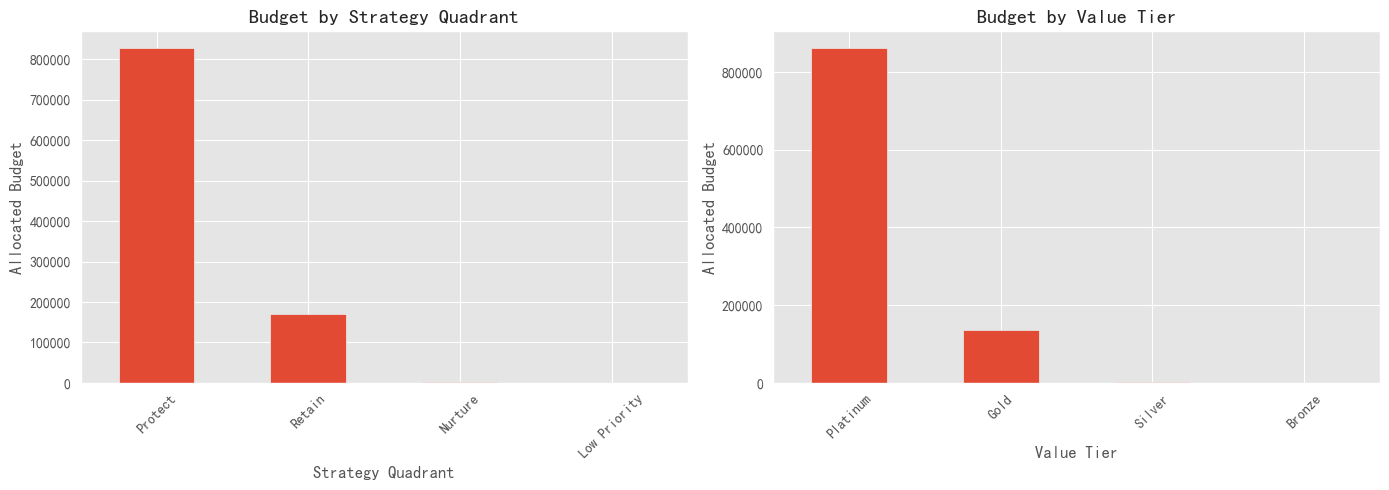

In [71]:
# 10.5 Visualize budget allocation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

budget_summary['budget_sum'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Budget by Strategy Quadrant')
axes[0].set_xlabel('Strategy Quadrant')
axes[0].set_ylabel('Allocated Budget')
axes[0].tick_params(axis='x', rotation=45)

budget_by_tier['budget_sum'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Budget by Value Tier')
axes[1].set_xlabel('Value Tier')
axes[1].set_ylabel('Allocated Budget')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'budget_allocation_overview.png', dpi=300)
plt.show()

In [72]:
# 10.6 Export customer-level budget results

budget_output_cols = [
    'customer_unique_id',
    'value_tier',
    'strategy_quadrant',
    'predicted_clv',
    'effective_risk_score',
    'allocated_budget'
]

df_model[budget_output_cols].to_csv(
    OUTPUT_DIR/'customer_budget_allocation.csv',
    index=False
)

print("Customer-level budget allocation file saved.")

Customer-level budget allocation file saved.


## Marketing Budget Allocation Analysis

The budget allocation is highly concentrated in a very small set of high-value customers. `Protect` and `Retain` receive almost all of the total budget, while `Nurture` and `Low Priority` receive little or nearly no investment.

This pattern is also visible at the tier level. Platinum and Gold absorb nearly all resources, whereas Silver receives only a small amount and Bronze effectively receives none. The result is consistent with the zero-heavy CLV structure, where most customers have little predicted future value.

At the same time, this strategy should be interpreted carefully. A highly concentrated allocation is efficient for short-term value capture, but it may also underinvest in lower-tier customers who could improve over time. So the current rule works well as a value-focused allocation scheme, but it is better seen as a first-pass prioritization policy than a complete long-term marketing strategy.

## 11. High-Value Customer Profiling

This section profiles the highest-value customers and compares them with the rest of the customer base.

In [73]:
# 11.1 Select high-value customers

top_customers = df_model[df_model['value_tier'].isin(['Platinum', 'Gold'])].copy()

print("High-value customer count:")
print(len(top_customers))

print("\nHigh-value tier distribution:")
print(top_customers['value_tier'].value_counts())

High-value customer count:
312

High-value tier distribution:
value_tier
Gold        187
Platinum    125
Name: count, dtype: int64


In [74]:
# 11.2 Build high-value customer profile

profile_features = [
    'predicted_clv',
    'future_6m_gmv',
    'total_orders',
    'total_gmv',
    'avg_order_value',
    'monthly_frequency',
    'days_since_last_order',
    'effective_risk_score',
    'avg_review_score',
    'delay_rate'
]

high_value_profile = top_customers[profile_features].describe().T.round(2)
high_value_profile['median'] = top_customers[profile_features].median().round(2)

print("High-value customer profile:")
print(high_value_profile[['mean', 'median', 'std', 'min', 'max']])

high_value_profile.to_csv(
    OUTPUT_DIR/'high_value_customer_profile.csv'
)

High-value customer profile:
                         mean  median     std    min      max
predicted_clv           67.94   36.36   88.92   0.82   461.14
future_6m_gmv          123.05   73.04  189.67   0.00  1535.88
total_orders             1.06    1.00    0.28   1.00     3.00
total_gmv              177.12  107.16  238.82  13.17  2626.07
avg_order_value        163.18  104.02  209.88  13.17  2626.07
monthly_frequency        1.01    1.00    0.14   0.43     2.00
days_since_last_order   60.73   46.50   50.55   0.00   269.00
effective_risk_score     0.57    0.60    0.19   0.06     0.98
avg_review_score         4.27    5.00    1.23   1.00     5.00
delay_rate               0.03    0.00    0.17   0.00     1.00


In [75]:
# 11.3 Compare high-value customers with others

other_customers = df_model[~df_model['customer_unique_id'].isin(top_customers['customer_unique_id'])].copy()

comparison = pd.DataFrame({
    'High_Value': top_customers[profile_features].mean(),
    'Others': other_customers[profile_features].mean()
}).round(2)

comparison['Difference'] = (comparison['High_Value'] - comparison['Others']).round(2)

print("High-value vs others:")
print(comparison)

comparison.to_csv(
    OUTPUT_DIR/'high_value_vs_others.csv'
)

High-value vs others:
                       High_Value  Others  Difference
predicted_clv               67.94    0.00       67.94
future_6m_gmv              123.05    0.00      123.05
total_orders                 1.06    1.02        0.04
total_gmv                  177.12  166.33       10.79
avg_order_value            163.18  163.15        0.03
monthly_frequency            1.01    1.02       -0.01
days_since_last_order       60.73   74.55      -13.82
effective_risk_score         0.57    0.65       -0.08
avg_review_score             4.27    4.20        0.07
delay_rate                   0.03    0.05       -0.02


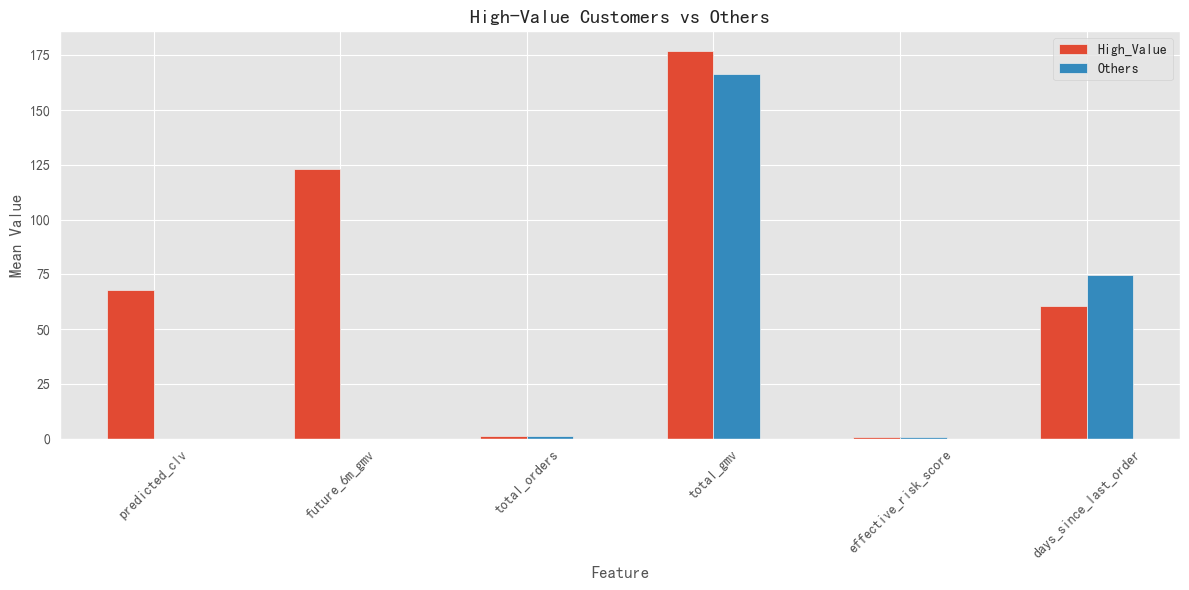

In [76]:
# 11.4 Visualize profile comparison

plot_features = [
    'predicted_clv',
    'future_6m_gmv',
    'total_orders',
    'total_gmv',
    'effective_risk_score',
    'days_since_last_order'
]

comparison_plot = comparison.loc[plot_features, ['High_Value', 'Others']]

comparison_plot.plot(kind='bar', figsize=(12, 6))
plt.title('High-Value Customers vs Others')
plt.xlabel('Feature')
plt.ylabel('Mean Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'high_value_vs_others.png', dpi=300)
plt.show()

In [77]:
# 11.5 Export high-value customer list

high_value_output_cols = [
    'customer_unique_id',
    'value_tier',
    'predicted_clv',
    'future_6m_gmv',
    'effective_risk_score',
    'effective_risk_level',
    'strategy_quadrant',
    'allocated_budget'
]

top_customers[high_value_output_cols].to_csv(
    OUTPUT_DIR/'high_value_customers.csv',
    index=False
)

print("High-value customer file saved.")

High-value customer file saved.


## High-Value Customer Profiling Analysis and Summary

A total of 312 customers are identified as high-value customers, including 187 Gold customers and 125 Platinum customers. This confirms that the high-value segment is very small relative to the full customer base.

Compared with others, high-value customers show much stronger value performance. Their average predicted CLV is 67.94, and their average actual future GMV is 123.05, while the rest of the customer base remains close to zero on both measures. They also have slightly higher historical GMV and are more recently active.

In addition, high-value customers appear healthier overall. Their average `days_since_last_order` is lower, their `effective_risk_score` is lower, and their review score is slightly higher than the rest of the population. This suggests that the top-value segment is not only more profitable, but also more stable in customer quality terms.

One result should still be read cautiously: `monthly_frequency` is not higher for the high-value group. This may reflect the single-purchase structure of many customers in the dataset, rather than a true lack of engagement. So the profile is directionally useful, but not every feature difference should be over-interpreted.

## 12. Validation and Tier Accuracy

This section evaluates how well the predicted CLV tiers match the actual future GMV tiers.

The goal is not only to measure overall tier classification performance, but also to check whether the model can **reliably distinguish the small number of truly high-value customers** from the much larger low-value majority.

In [78]:
# 12.1 Create actual value tiers from future GMV (holdout only)

df_test_eval['actual_value_tier'] = 'Bronze'

positive_actual_mask = df_test_eval['future_6m_gmv'] > 0
df_actual_positive = df_test_eval.loc[
    positive_actual_mask,
    ['customer_unique_id', 'future_6m_gmv']
].copy()

if len(df_actual_positive) > 0:
    df_actual_positive['actual_percentile'] = df_actual_positive['future_6m_gmv'].rank(
        method='first',
        pct=True
    )

    def assign_actual_tier(percentile):
        if percentile >= 0.80:
            return 'Platinum'
        elif percentile >= 0.50:
            return 'Gold'
        else:
            return 'Silver'

    df_actual_positive['actual_value_tier'] = df_actual_positive['actual_percentile'].apply(
        assign_actual_tier
    )

    df_test_eval = df_test_eval.drop(columns=['actual_value_tier'], errors='ignore').merge(
        df_actual_positive[['customer_unique_id', 'actual_value_tier']],
        on='customer_unique_id',
        how='left'
    )

    df_test_eval['actual_value_tier'] = df_test_eval['actual_value_tier'].fillna('Bronze')

print("Actual tier distribution:")
print(df_test_eval['actual_value_tier'].value_counts())

Actual tier distribution:
actual_value_tier
Bronze      2709
Silver        21
Gold          14
Platinum       9
Name: count, dtype: int64


In [79]:
# 12.2 Build tier confusion matrix

from sklearn.metrics import confusion_matrix

tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']

# Synchronize the prediction hierarchical results from df_model to the Holdout Evaluation Table
pred_tier_map = (
    df_model[['customer_unique_id', 'value_tier']]
    .drop_duplicates(subset=['customer_unique_id'])
    .copy()
)

df_test_eval = (
    df_test_eval
    .drop(columns=['value_tier'], errors='ignore')
    .merge(
        pred_tier_map,
        on='customer_unique_id',
        how='left'
    )
)

df_test_eval['value_tier'] = df_test_eval['value_tier'].fillna('Bronze')

print("Validation columns check:")
print(df_test_eval[['customer_unique_id', 'actual_value_tier', 'value_tier']].head())

cm = confusion_matrix(
    df_test_eval['actual_value_tier'],
    df_test_eval['value_tier'],
    labels=tier_order
)

cm_df = pd.DataFrame(
    cm,
    index=[f'Actual_{t}' for t in tier_order],
    columns=[f'Pred_{t}' for t in tier_order]
)

print("Tier confusion matrix:")
print(cm_df)

Validation columns check:
                 customer_unique_id actual_value_tier value_tier
0  46587168f28103639ae8249f19b53043            Bronze     Bronze
1  62005030b1a2bad3360ff68271a75edf            Bronze     Bronze
2  997bdee4984cf6061062303a6a5f6c97            Bronze     Bronze
3  f4e294b108865ee25da71f30a838b8d0            Bronze     Bronze
4  31284ff65b82dd9571b788b1c3644fb4            Bronze     Bronze
Tier confusion matrix:
                 Pred_Bronze  Pred_Silver  Pred_Gold  Pred_Platinum
Actual_Bronze           2625           63         20              1
Actual_Silver              0            0         13              8
Actual_Gold                0            0          5              9
Actual_Platinum            0            0          5              4


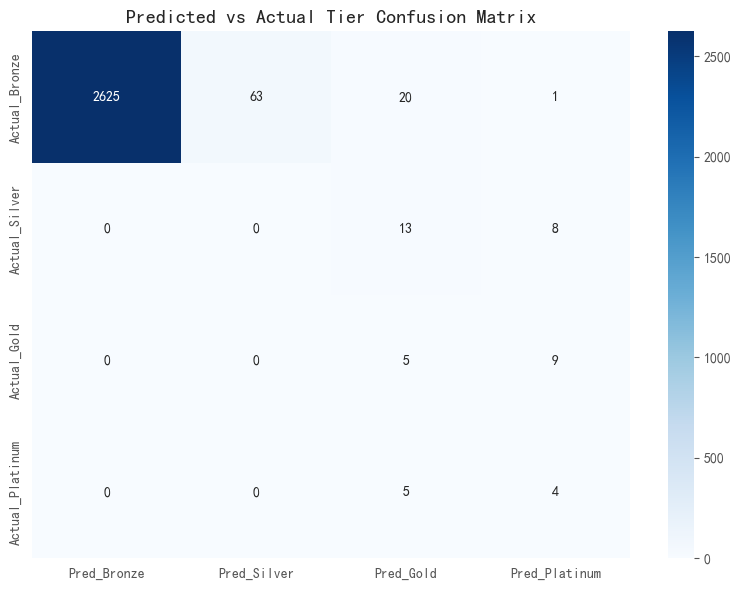

In [80]:
# 12.3 Visualize tier confusion matrix

import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title('Predicted vs Actual Tier Confusion Matrix')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'tier_confusion_matrix.png', dpi=300)
plt.show()

In [81]:
# 12.4 Classification report by tier

from sklearn.metrics import classification_report

tier_report = classification_report(
    df_test_eval['actual_value_tier'],
    df_test_eval['value_tier'],
    labels=tier_order,
    output_dict=True,
    zero_division=0
)

tier_report_df = pd.DataFrame(tier_report).T.round(4)

print("Tier classification report:")
print(tier_report_df)

tier_report_df.to_csv(
    OUTPUT_DIR/'tier_classification_report.csv'
)

Tier classification report:
              precision  recall  f1-score    support
Bronze           1.0000  0.9690    0.9843  2709.0000
Silver           0.0000  0.0000    0.0000    21.0000
Gold             0.1163  0.3571    0.1754    14.0000
Platinum         0.1818  0.4444    0.2581     9.0000
accuracy         0.9568  0.9568    0.9568     0.9568
macro avg        0.3245  0.4426    0.3544  2753.0000
weighted avg     0.9852  0.9568    0.9703  2753.0000


In [82]:
# 12.5 Evaluate top-customer identification

df_test_eval['is_top_actual'] = df_test_eval['actual_value_tier'].isin(['Platinum', 'Gold']).astype(int)
df_test_eval['is_top_predicted'] = df_test_eval['value_tier'].isin(['Platinum', 'Gold']).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

top_precision = precision_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'], zero_division=0)
top_recall = recall_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'], zero_division=0)
top_f1 = f1_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'], zero_division=0)
top_accuracy = accuracy_score(df_test_eval['is_top_actual'], df_test_eval['is_top_predicted'])

print("Top-customer identification metrics:")
print(f"Precision: {top_precision:.4f}")
print(f"Recall:    {top_recall:.4f}")
print(f"F1-score:  {top_f1:.4f}")
print(f"Accuracy:  {top_accuracy:.4f}")

Top-customer identification metrics:
Precision: 0.3538
Recall:    1.0000
F1-score:  0.5227
Accuracy:  0.9847


In [83]:
# 12.6 Export validation results

validation_output_cols = [
    'customer_unique_id',
    'predicted_clv',
    'future_6m_gmv',
    'value_tier',
    'actual_value_tier',
    'is_top_predicted',
    'is_top_actual'
]

df_test_eval[validation_output_cols].to_csv(
    OUTPUT_DIR/'tier_validation_results.csv',
    index=False
)

print("Validation file saved.")

Validation file saved.


## Validation and Tier Accuracy Analysis and Summary

The validation results show that the tiering framework works **very well for the Bronze majority**, but is much less precise for the smaller positive-value tiers. Bronze customers are classified strongly, with **precision = 1.0000**, **recall = 0.9690**, and **F1 = 0.9843**. This explains the high overall accuracy of **0.9568**.

However, the confusion matrix also shows that **Silver, Gold, and Platinum are not separated equally well**. Silver is not identified successfully in this holdout split, while Gold and Platinum have only modest precision and recall. This suggests that the current tiering logic is much better at identifying **non-value customers** than at making fine distinctions within the small high-value minority.

The top-customer identification result is still useful. The model achieves **precision = 0.3538**, **recall = 1.0000**, and **F1 = 0.5227**. In practice, this means the model is very good at **capturing all actual top customers**, but it also brings in a noticeable number of false positives. So the validation result is encouraging for screening and prioritization, but it is **not yet strong enough to claim highly accurate tier separation across all value levels**.

## 13. Business Insights and Final Summary

This section summarizes the main findings and exports the final CLV outputs.

The purpose is to translate model results into a compact business view, while also reflecting on the limits of the current CLV framework.

In [84]:
# 13.1 Build key metrics summary

top_feature_names = feature_importance.head(5)['feature'].tolist()

final_metrics = {
    'best_model': best_model_name,
    'rmse_log': float(results_df.iloc[0]['RMSE_log']),
    'r2_log': float(results_df.iloc[0]['R2_log']),
    'mae_raw': float(results_df.iloc[0]['MAE_raw']),
    'rmse_raw': float(results_df.iloc[0]['RMSE_raw']),
    'top_customer_precision': float(top_precision),
    'top_customer_recall': float(top_recall),
    'top_customer_f1': float(top_f1),
    'high_value_customer_count':int(df_model['value_tier'].isin(['Platinum', 'Gold']).sum()),
    'top_5_features': ', '.join(top_feature_names)
}

final_metrics_df = pd.DataFrame(
    list(final_metrics.items()),
    columns=['metric', 'value']
)

print("Final metrics summary:")
print(final_metrics_df)

final_metrics_df.to_csv(
    OUTPUT_DIR / 'final_metrics_summary.csv',
    index=False
)

Final metrics summary:
                      metric  \
0                 best_model   
1                   rmse_log   
2                     r2_log   
3                    mae_raw   
4                   rmse_raw   
5     top_customer_precision   
6        top_customer_recall   
7            top_customer_f1   
8  high_value_customer_count   
9             top_5_features   

                                               value  
0                                      Random Forest  
1                                           0.263725  
2                                           0.811172  
3                                           2.083725  
4                                          35.493779  
5                                           0.353846  
6                                                1.0  
7                                           0.522727  
8                                                312  
9  R_score, total_orders, F_score, exploration_ra...  


In [85]:
# 13.2 Generate business insights text

top10_n = max(1, int(len(df_model) * 0.10))
top10_customers = df_model.nlargest(top10_n, 'predicted_clv')

total_actual_gmv = df_model['future_6m_gmv'].sum()
if total_actual_gmv > 0:
    top10_gmv_contribution = top10_customers['future_6m_gmv'].sum() / total_actual_gmv
else:
    top10_gmv_contribution = 0.0

platinum_avg_clv = tier_stats.loc['Platinum', 'predicted_clv_mean'] if 'Platinum' in tier_stats.index else 0.0
bronze_avg_clv = tier_stats.loc['Bronze', 'predicted_clv_mean'] if 'Bronze' in tier_stats.index else 0.0

top5_feature_lines = '\n'.join(
    [f"- {row['feature']}: {row['importance']:.4f}" for _, row in feature_importance.head(5).iterrows()]
)

platinum_budget_per_customer = (
    budget_by_tier.loc['Platinum', 'budget_mean'] if 'Platinum' in budget_by_tier.index else 0.0
)

platinum_expected_roi = 0.0
if 'Platinum' in budget_by_tier.index and budget_by_tier.loc['Platinum', 'budget_sum'] > 0:
    platinum_expected_roi = (
        budget_by_tier.loc['Platinum', 'predicted_clv_sum'] /
        budget_by_tier.loc['Platinum', 'budget_sum']
    )

insights_text = f"""
# CLV Prediction Project - Business Insights

## 1. Model Performance
- Best model: {best_model_name}
- RMSE on log target: {results_df.iloc[0]['RMSE_log']:.4f}
- R² on log target: {results_df.iloc[0]['R2_log']:.4f}
- MAE on raw target: {results_df.iloc[0]['MAE_raw']:.4f}
- RMSE on raw target: {results_df.iloc[0]['RMSE_raw']:.4f}

## 2. Customer Value Distribution
- Top 10% customer contribution: {top10_gmv_contribution:.2%} of total future GMV
- Platinum average predicted CLV: {platinum_avg_clv:.2f}
- Bronze average predicted CLV: {bronze_avg_clv:.2f}

## 3. Top 5 Predictive Factors
{top5_feature_lines}

## 4. Value-Risk Findings
{strategy_summary.to_string()}

## 5. Marketing Budget Suggestions
- Platinum budget per customer: {platinum_budget_per_customer:.2f}
- Platinum expected ROI: {platinum_expected_roi:.2f}x

## 6. Business Actions
1. Focus on high-value customers with VIP-style retention and service.
2. Apply differentiated marketing by customer value tier.
3. Prioritize urgent retention for high-value high-risk customers.
4. Develop uplift strategies for lower-value but promising customers.
5. Evaluate acquisition efficiency with a CLV-to-CAC logic.
"""

print(insights_text)

with open(OUTPUT_DIR / 'business_insights.md', 'w', encoding='utf-8') as f:
    f.write(insights_text)


# CLV Prediction Project - Business Insights

## 1. Model Performance
- Best model: Random Forest
- RMSE on log target: 0.2637
- R² on log target: 0.8112
- MAE on raw target: 2.0837
- RMSE on raw target: 35.4938

## 2. Customer Value Distribution
- Top 10% customer contribution: 100.00% of total future GMV
- Platinum average predicted CLV: 146.29
- Bronze average predicted CLV: 0.00

## 3. Top 5 Predictive Factors
- R_score: 0.6299
- total_orders: 0.0573
- F_score: 0.0558
- exploration_rate: 0.0498
- unique_products_purchased: 0.0336

## 4. Value-Risk Findings
                   customer_count  predicted_clv_mean  predicted_clv_sum  actual_gmv_mean  actual_gmv_sum  risk_score_mean
strategy_quadrant                                                                                                         
Protect                       269               67.64           18195.14           120.92        32528.06             0.53
Retain                         43               69.79          

In [86]:
# 13.3 Export final full results

final_output_cols = [
    'customer_unique_id',
    'future_6m_gmv',
    'predicted_clv',
    'value_tier',
    'actual_value_tier',
    'clv_group',
    'risk_group',
    'strategy_quadrant',
    'effective_risk_score',
    'effective_risk_level',
    'allocated_budget',
    'is_top_predicted',
    'is_top_actual'
]

optional_cols = [
    'R_score', 'F_score', 'M_score', 'rfm_score',
    'total_orders', 'total_gmv', 'avg_order_value',
    'monthly_frequency', 'days_since_last_order',
    'value_potential', 'recency_score', 'customer_maturity'
]

final_export_cols = final_output_cols + [
    col for col in optional_cols if col in df_model.columns
]

df_model[final_export_cols].to_csv(
    OUTPUT_DIR / 'clv_prediction_full_results.csv',
    index=False
)

print("Full results file saved.")

KeyError: "['actual_value_tier', 'is_top_predicted', 'is_top_actual'] not in index"

In [90]:
# 13.3A Duplicate export removed intentionally

print("Duplicate full-results export removed. Use the previous cell as the single source of truth.")


Duplicate full-results export removed. Use the previous cell as the single source of truth.


## Analysis and Summary

The final CLV workflow is complete. The project produces **customer-level CLV predictions**, **value tiers**, **value-risk segmentation**, **budget allocation outputs**, and **validation results**.

The results show a **highly concentrated value structure**. Most customers are predicted to have zero future value, while a very small minority drives the meaningful CLV signal. The best-performing model is **Random Forest**, and the strongest predictive signals come mainly from **RFM and recency-related features**, especially **R_score**.

From a business perspective, the project supports a clear action framework: **protect lower-risk high-value customers**, **retain high-value but risky customers**, **nurture lower-value customers with some upside**, and **limit spend on low-priority groups**.

At the same time, the final results should be interpreted carefully. The model performs strongly overall, but much of that strength comes from separating the large low-value majority from the small positive-value minority. So this version is already useful for prioritization and segmentation, but it is **more reliable for broad screening than for very fine-grained ranking within the top-value group**.

# CLV Prediction Project - Business Insights

## 1. Model Performance
- **Best model:** Random Forest
- **RMSE (log):** 0.2637
- **R² (log):** 0.8112
- **MAE (raw):** 2.0837
- **RMSE (raw):** 35.4938

## 2. Customer Value Structure
- **Customer value is highly concentrated.**
- **98.4%** of customers have zero future GMV.
- Only **312 customers** are identified as high-value customers.

## 3. Key Predictive Signals
- Top features include **R_score**, **total_orders**, **F_score**, **exploration_rate**, and **effective_risk_score**.
- **R_score** is the strongest signal in the final model.

## 4. Value-Risk Findings
- **Protect (269)** and **Retain (43)** are the most important groups.
- Most customers remain in **Nurture (8936)** or **Low Priority (4515)**.

## 5. Budget Allocation
- Budget is concentrated in **Platinum** and **Gold** customers.
- **Protect** and **Retain** receive almost all strategic budget.

## 6. Validation
- Overall tier accuracy is **0.9568**, but this is driven mainly by strong Bronze classification.
- Top-customer identification:
  - **Precision:** 0.3538
  - **Recall:** 1.0000
  - **F1-score:** 0.5227

## 7. Business Actions
1. **Protect** stable high-value customers with priority service and loyalty actions.
2. **Retain** high-value high-risk customers with targeted retention offers.
3. Use **tier-based marketing** instead of broad uniform campaigns.
4. Keep monitoring **recency and RFM signals** in future CLV updates.
5. Treat this version as a **strong prioritization tool**, but not yet as a fully precise ranking system for all high-value customers.

## 13.4 Data Quality Diagnostics

This section adds a compact QA report so the final CLV outputs can be checked before delivery.

In [92]:
# 13.4 Generate data quality diagnostic report

print("=" * 80)
print("DATA QUALITY DIAGNOSTIC REPORT")
print("=" * 80)

print("\n1. Customer Activity Analysis:")
print(f"   Total customers: {len(df_model):,}")
print(
    f"   Customers with predicted_clv > 0: {(df_model['predicted_clv'] > 0).sum():,} "
    f"({(df_model['predicted_clv'] > 0).sum() / len(df_model) * 100:.1f}%)"
)
print(
    f"   Customers with predicted_clv = 0: {(df_model['predicted_clv'] == 0).sum():,} "
    f"({(df_model['predicted_clv'] == 0).sum() / len(df_model) * 100:.1f}%)"
)

print("\n2. Days Since Last Order Distribution:")
dslo_stats = df_model['days_since_last_order'].describe()
print(dslo_stats)
print(f"   Customers inactive >365 days: {(df_model['days_since_last_order'] > 365).sum():,}")
print(f"   Customers inactive >180 days: {(df_model['days_since_last_order'] > 180).sum():,}")
print(f"   Customers inactive >90 days: {(df_model['days_since_last_order'] > 90).sum():,}")

print("\n3. Predicted CLV Distribution (for CLV > 0):")
positive_clv = df_model.loc[df_model['predicted_clv'] > 0, 'predicted_clv']
print(positive_clv.describe() if len(positive_clv) > 0 else "   No positive predicted CLV values found.")

print("\n4. Actual vs Predicted Consistency:")
has_future_gmv = (df_model['future_6m_gmv'] > 0).sum()
has_predicted_clv = (df_model['predicted_clv'] > 0).sum()
both_positive = ((df_model['future_6m_gmv'] > 0) & (df_model['predicted_clv'] > 0)).sum()
print(f"   Customers with actual future GMV > 0: {has_future_gmv:,}")
print(f"   Customers with predicted CLV > 0: {has_predicted_clv:,}")
print(f"   Overlap (both > 0): {both_positive:,}")

print("\n5. Feature Missing Values:")
missing_summary = df_model[feature_columns].isnull().sum()
if missing_summary.sum() > 0:
    print(missing_summary[missing_summary > 0])
else:
    print("   No missing values found")

print("\n6. Outlier Detection:")
for col in ['total_orders', 'total_gmv', 'days_since_last_order']:
    q1 = df_model[col].quantile(0.25)
    q3 = df_model[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((df_model[col] < q1 - 1.5 * iqr) | (df_model[col] > q3 + 1.5 * iqr)).sum()
    print(f"   {col}: {outliers} outliers ({outliers / len(df_model) * 100:.1f}%)")

print("\n" + "=" * 80)

diagnostic_summary = pd.DataFrame({
    'metric': [
        'total_customers',
        'customers_clv_positive',
        'customers_clv_zero',
        'customers_inactive_365d',
        'customers_inactive_180d',
        'customers_inactive_90d',
        'avg_days_since_last_order',
        'median_days_since_last_order'
    ],
    'value': [
        len(df_model),
        (df_model['predicted_clv'] > 0).sum(),
        (df_model['predicted_clv'] == 0).sum(),
        (df_model['days_since_last_order'] > 365).sum(),
        (df_model['days_since_last_order'] > 180).sum(),
        (df_model['days_since_last_order'] > 90).sum(),
        df_model['days_since_last_order'].mean(),
        df_model['days_since_last_order'].median()
    ]
})

diagnostic_summary.to_csv(
    OUTPUT_DIR / 'data_quality_diagnostics.csv',
    index=False
)
print(f"\nDiagnostic report saved to {OUTPUT_DIR / 'data_quality_diagnostics.csv'}")


DATA QUALITY DIAGNOSTIC REPORT

1. Customer Activity Analysis:
   Total customers: 13,763
   Customers with predicted_clv > 0: 623 (4.5%)
   Customers with predicted_clv = 0: 13,140 (95.5%)

2. Days Since Last Order Distribution:
count    13763.000000
mean        74.238756
std         52.336732
min          0.000000
25%         32.000000
50%         65.000000
75%        109.000000
max        287.000000
Name: days_since_last_order, dtype: float64
   Customers inactive >365 days: 0
   Customers inactive >180 days: 262
   Customers inactive >90 days: 4,996

3. Predicted CLV Distribution (for CLV > 0):
count    623.000000
mean      34.123335
std       71.432752
min        0.001976
25%        0.096243
50%        0.817431
75%       36.356449
max      461.143959
Name: predicted_clv, dtype: float64

4. Actual vs Predicted Consistency:
   Customers with actual future GMV > 0: 220
   Customers with predicted CLV > 0: 623
   Overlap (both > 0): 220

5. Feature Missing Values:
   No missing values

In [93]:
# 13.5 Consolidate and clean outputs

from pathlib import Path
import shutil
import os

CURRENT_NOTEBOOK_DIR = Path.cwd()
LEGACY_OUTPUT_DIR = CURRENT_NOTEBOOK_DIR / 'output' / '07_clv_prediction'
FINAL_OUTPUT_DIR = CURRENT_NOTEBOOK_DIR.parent / 'output' / '07_clv_prediction'

FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

keep_files = {
    'final_metrics_summary.csv',
    'business_insights.md',
    'clv_prediction_full_results.csv',
    'model_comparison_log_target.csv',
    'model_comparison_log_target.png',
    'feature_importance_rf.csv',
    'feature_importance_permutation.csv',
    'feature_importance_top15_rf.png',
    'customer_value_tiers.csv',
    'customer_tier_statistics.csv',
    'customer_tier_overview.png',
    'strategy_quadrant_summary.csv',
    'value_risk_matrix_heatmap.png',
    'value_risk_scatter.png',
    'budget_allocation_by_strategy.csv',
    'budget_allocation_by_tier.csv',
    'budget_allocation_overview.png',
    'customer_budget_allocation.csv',
    'high_value_customers.csv',
    'high_value_customer_profile.csv',
    'tier_classification_report.csv',
    'tier_confusion_matrix.png',
    'tier_validation_results.csv',
    'best_model_actual_vs_predicted.png',
    'best_model_residual_diagnostics.png',
    'target_distribution.png',
    'target_pareto_curve.png',
    'selected_feature_distributions.png',
    'feature_correlation_matrix.png',
    'data_quality_diagnostics.csv'
}

# Move legacy files from Statistical_analysis_report/output/07_clv_prediction
if LEGACY_OUTPUT_DIR.exists() and LEGACY_OUTPUT_DIR.resolve() != FINAL_OUTPUT_DIR.resolve():
    for file_path in LEGACY_OUTPUT_DIR.iterdir():
        if file_path.is_file():
            target_path = FINAL_OUTPUT_DIR / file_path.name
            if target_path.exists():
                file_path.unlink()
            else:
                shutil.move(str(file_path), str(target_path))

# Remove Windows nul artifact if it exists
nul_candidates = [
    CURRENT_NOTEBOOK_DIR / 'nul',
    CURRENT_NOTEBOOK_DIR.parent / 'nul'
]

removed_nul = []
for nul_path in nul_candidates:
    if nul_path.exists() and nul_path.is_file():
        nul_path.unlink()
        removed_nul.append(str(nul_path))

# Remove files not in keep list
removed_files = []
for file_path in FINAL_OUTPUT_DIR.iterdir():
    if file_path.is_file() and file_path.name not in keep_files:
        file_path.unlink()
        removed_files.append(file_path.name)

# Remove empty legacy directory if possible
if LEGACY_OUTPUT_DIR.exists() and LEGACY_OUTPUT_DIR.resolve() != FINAL_OUTPUT_DIR.resolve():
    try:
        LEGACY_OUTPUT_DIR.rmdir()
        legacy_removed = True
    except OSError:
        legacy_removed = False
else:
    legacy_removed = False

expected_files = sorted(keep_files)
missing_files = [name for name in expected_files if not (FINAL_OUTPUT_DIR / name).exists()]

print("Final output directory:")
print(FINAL_OUTPUT_DIR)

print("\nKept files:")
for name in sorted([f.name for f in FINAL_OUTPUT_DIR.iterdir() if f.is_file()]):
    print("-", name)

print("\nRemoved files:")
for name in sorted(removed_files):
    print("-", name)

print("\nRemoved nul artifacts:")
for name in removed_nul:
    print("-", name)

print("\nMissing expected files:")
for name in missing_files:
    print("-", name)

print("\nLegacy output directory removed:", legacy_removed)


Final output directory:
C:\Users\wangxinxin\Documents\GitHub\E-commerce_decision-making-_intelligence\output\07_clv_prediction

Kept files:
- best_model_actual_vs_predicted.png
- best_model_residual_diagnostics.png
- budget_allocation_by_strategy.csv
- budget_allocation_by_tier.csv
- budget_allocation_overview.png
- business_insights.md
- clv_prediction_full_results.csv
- customer_budget_allocation.csv
- customer_tier_overview.png
- customer_tier_statistics.csv
- customer_value_tiers.csv
- data_quality_diagnostics.csv
- feature_correlation_matrix.png
- feature_importance_permutation.csv
- feature_importance_rf.csv
- feature_importance_top15_rf.png
- final_metrics_summary.csv
- high_value_customer_profile.csv
- high_value_customers.csv
- model_comparison_log_target.csv
- model_comparison_log_target.png
- selected_feature_distributions.png
- strategy_quadrant_summary.csv
- target_distribution.png
- target_pareto_curve.png
- tier_classification_report.csv
- tier_confusion_matrix.png
- tie